<a href="https://colab.research.google.com/github/Arce369/Machine-Learning/blob/main/Supervised%20learning/G-Credit-Classification/Notebook" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ensambles: Predicción de Riesgo Crediticio
## **German Credit dataset**
En este dataset clasifica a las personas, en función de una serie de atributos, como de bajo o alto riesgo crediticio.

## **Modelado en Python**

Realizaremos la modelación del conjunto de datos para una **respuesta binaria**, empleando una familia de modelos de clasificación orientados a ensambles y meta‑aprendizaje. En particular, utilizaremos:

### 🔹 **Modelos base (árboles y boosting)**
- `XGBClassifier`  
- `GradientBoostingClassifier`  
- `RandomForestClassifier`  

### 🔹 **Modelo ensamblado (Stacking)**
Implementaremos un esquema de *stacking* con dos niveles:

#### **Nivel 0 — Base learners**
- Random Forest  
- XGBoost  
- Gradient Boosting  

#### **Nivel 1 — Meta‑learner**
- Regresión logística con validación cruzada interna  
- Implementado mediante `StackingClassifier` de *scikit‑learn*

Este enfoque permite capturar patrones complementarios entre modelos basados en árboles, mejorando la capacidad predictiva y la estabilidad del sistema de clasificación.


In [ ]:
#@title Environment
import matplotlib.pyplot as plt, seaborn as sns, numpy as np, time, gc

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier
from sklearn.linear_model import LogisticRegressionCV
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import LabelEncoder

from sklearn.datasets import fetch_openml
!pip install -q ucimlrepo
import pandas as pd


import xgboost as xgb

### Carga de datos y EDA rápido

In [ ]:
# ============================================================
# 1. Intento primario: UCIMLRepo (Statlog German Credit)
# ============================================================
try:
    print("Intentando cargar German Credit desde UCIMLRepo...")
    from ucimlrepo import fetch_ucirepo

    statlog_german_credit_data = fetch_ucirepo(id=144)

    X = statlog_german_credit_data.data.features
    y = statlog_german_credit_data.data.targets


    # Unir X + y
    df = pd.concat([X, y], axis=1)

    # ============================================================
    # Mapeo de columnas UCIMLRepo → nombres clásicos
    # ============================================================
    mapping_cols = {
        "Attribute1": "checking_status",
        "Attribute2": "duration",
        "Attribute3": "credit_history",
        "Attribute4": "purpose",
        "Attribute5": "credit_amount",
        "Attribute6": "savings_status",
        "Attribute7": "employment",
        "Attribute8": "installment_commitment",
        "Attribute9": "personal_status",
        "Attribute10": "other_parties",
        "Attribute11": "residence_since",
        "Attribute12": "property_magnitude",
        "Attribute13": "age",
        "Attribute14": "other_payment_plans",
        "Attribute15": "housing",
        "Attribute16": "existing_credits",
        "Attribute17": "job",
        "Attribute18": "num_dependents",
        "Attribute19": "own_telephone",
        "Attribute20": "foreign_worker",
        "class": "target"
    }

    df = df.rename(columns=mapping_cols)


    # Target: 1 = Good, 2 = Bad → queremos 1 = bad
    df["target"] = (df["target"] == 2).astype(int)

    print("✓ Dataset cargado y mapeado desde UCIMLRepo")

# ============================================================
# 2. Fallback: OpenML (data_id=31)
# ============================================================
except Exception as e:
    print("⚠️ UCIMLRepo falló, intentando cargar desde OpenML...")

    data = fetch_openml(data_id=31, as_frame=True, parser="pandas")
    df = data.frame.copy()

    df["target"] = (df["class"] == "bad").astype(int)
    df = df.drop(columns=["class"])

    print("✓ Dataset cargado exitosamente desde OpenML")


print("✓ Dataset final listo para modelado")
df.head()


Intentando cargar German Credit desde UCIMLRepo...
✓ Dataset cargado y mapeado desde UCIMLRepo
✓ Dataset final listo para modelado


,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,1


In [ ]:
pd.set_option('display.max_columns', None)
# ============================================================
# Normalización de categorías UCIMLRepo → valores semánticos
# ============================================================

# checking_status
df["checking_status"] = df["checking_status"].replace({
    "A11": "<0",
    "A12": "0<=X<200",
    "A13": ">=200",
    "A14": "no checking"
})

# savings_status
df["savings_status"] = df["savings_status"].replace({
    "A61": "<100",
    "A62": "100<=X<500",
    "A63": "500<=X<1000",
    "A64": ">=1000",
    "A65": "no known savings"
})

# employment
df["employment"] = df["employment"].replace({
    "A71": "unemployed",
    "A72": "<1",
    "A73": "1<=X<4",
    "A74": "4<=X<7",
    "A75": ">=7"
})

# foreign_worker
df["foreign_worker"] = df["foreign_worker"].replace({
    "A201": "yes",
    "A202": "no"
})

# credit_history
df["credit_history"] = df["credit_history"].replace({
    "A30": "no credits",
    "A31": "all paid",
    "A32": "existing paid",
    "A33": "delay",
    "A34": "critical"
})

# housing
df["housing"] = df["housing"].replace({
    "A151": "rent",
    "A152": "own",
    "A153": "free"
})

df.to_csv("/german_credit.csv", index=False)
df.head()

,checking_status,duration,credit_history,purpose,credit_amount,savings_status,employment,installment_commitment,personal_status,other_parties,residence_since,property_magnitude,age,other_payment_plans,housing,existing_credits,job,num_dependents,own_telephone,foreign_worker,target
0,<0,6,critical,A43,1169,no known savings,>=7,4,A93,A101,4,A121,67,A143,own,2,A173,1,A192,yes,0
1,0<=X<200,48,existing paid,A43,5951,<100,1<=X<4,2,A92,A101,2,A121,22,A143,own,1,A173,1,A191,yes,1
2,no checking,12,critical,A46,2096,<100,4<=X<7,2,A93,A101,3,A121,49,A143,own,1,A172,2,A191,yes,0
3,<0,42,existing paid,A42,7882,<100,4<=X<7,2,A93,A103,4,A122,45,A143,free,1,A173,2,A191,yes,0
4,<0,24,delay,A40,4870,<100,1<=X<4,3,A93,A101,4,A124,53,A143,free,2,A173,2,A191,yes,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   checking_status         1000 non-null   object
 1   duration                1000 non-null   int64 
 2   credit_history          1000 non-null   object
 3   purpose                 1000 non-null   object
 4   credit_amount           1000 non-null   int64 
 5   savings_status          1000 non-null   object
 6   employment              1000 non-null   object
 7   installment_commitment  1000 non-null   int64 
 8   personal_status         1000 non-null   object
 9   other_parties           1000 non-null   object
 10  residence_since         1000 non-null   int64 
 11  property_magnitude      1000 non-null   object
 12  age                     1000 non-null   int64 
 13  other_payment_plans     1000 non-null   object
 14  housing                 1000 non-null   object
 15  exist

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
duration,1000.0,20.903,12.058814,4.0,12.0,18.0,24.00,72.0
credit_amount,1000.0,3271.258,2822.736876,250.0,1365.5,2319.5,3972.25,18424.0
installment_commitment,1000.0,2.973,1.118715,1.0,2.0,3.0,4.00,4.0
residence_since,1000.0,2.845,1.103718,1.0,2.0,3.0,4.00,4.0
age,1000.0,35.546,11.375469,19.0,27.0,33.0,42.00,75.0
existing_credits,1000.0,1.407,0.577654,1.0,1.0,1.0,2.00,4.0
num_dependents,1000.0,1.155,0.362086,1.0,1.0,1.0,1.00,2.0
target,1000.0,0.300,0.458487,0.0,0.0,0.0,1.00,1.0


array([[<Axes: xlabel='duration', ylabel='duration'>,
        <Axes: xlabel='credit_amount', ylabel='duration'>,
        <Axes: xlabel='installment_commitment', ylabel='duration'>,
        <Axes: xlabel='residence_since', ylabel='duration'>,
        <Axes: xlabel='age', ylabel='duration'>,
        <Axes: xlabel='existing_credits', ylabel='duration'>,
        <Axes: xlabel='num_dependents', ylabel='duration'>,
        <Axes: xlabel='target', ylabel='duration'>],
       [<Axes: xlabel='duration', ylabel='credit_amount'>,
        <Axes: xlabel='credit_amount', ylabel='credit_amount'>,
        <Axes: xlabel='installment_commitment', ylabel='credit_amount'>,
        <Axes: xlabel='residence_since', ylabel='credit_amount'>,
        <Axes: xlabel='age', ylabel='credit_amount'>,
        <Axes: xlabel='existing_credits', ylabel='credit_amount'>,
        <Axes: xlabel='num_dependents', ylabel='credit_amount'>,
        <Axes: xlabel='target', ylabel='credit_amount'>],
       [<Axes: xlabel='durat

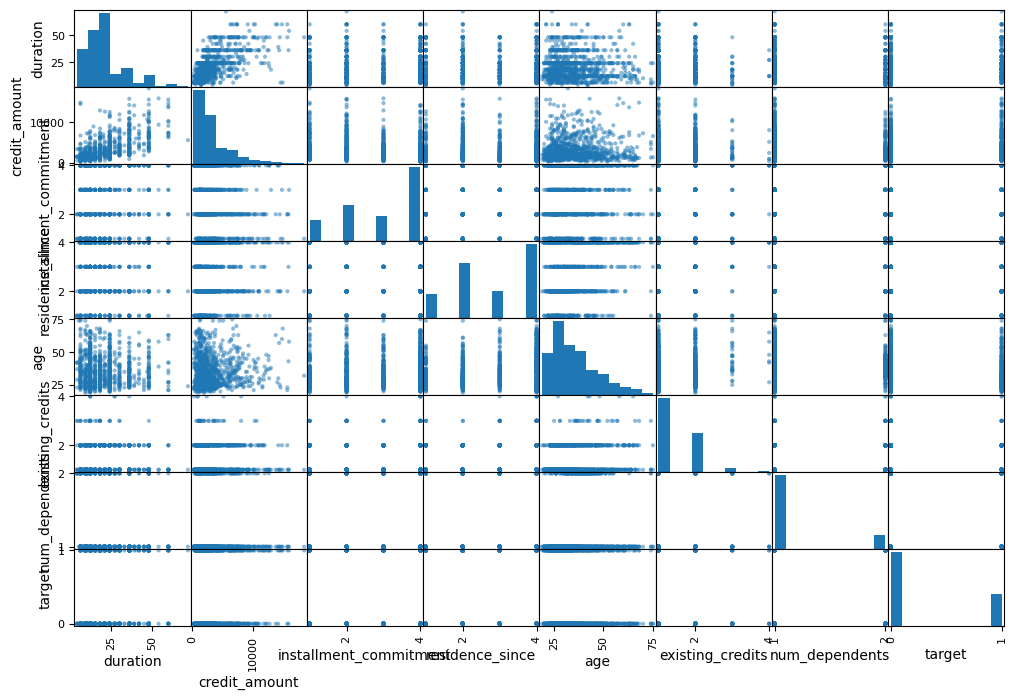

In [ ]:
df_categorical = df.select_dtypes(exclude=['number'])
df_numerical = df.select_dtypes(include=['number'])

pd.plotting.scatter_matrix(df_numerical, figsize=(12, 8))

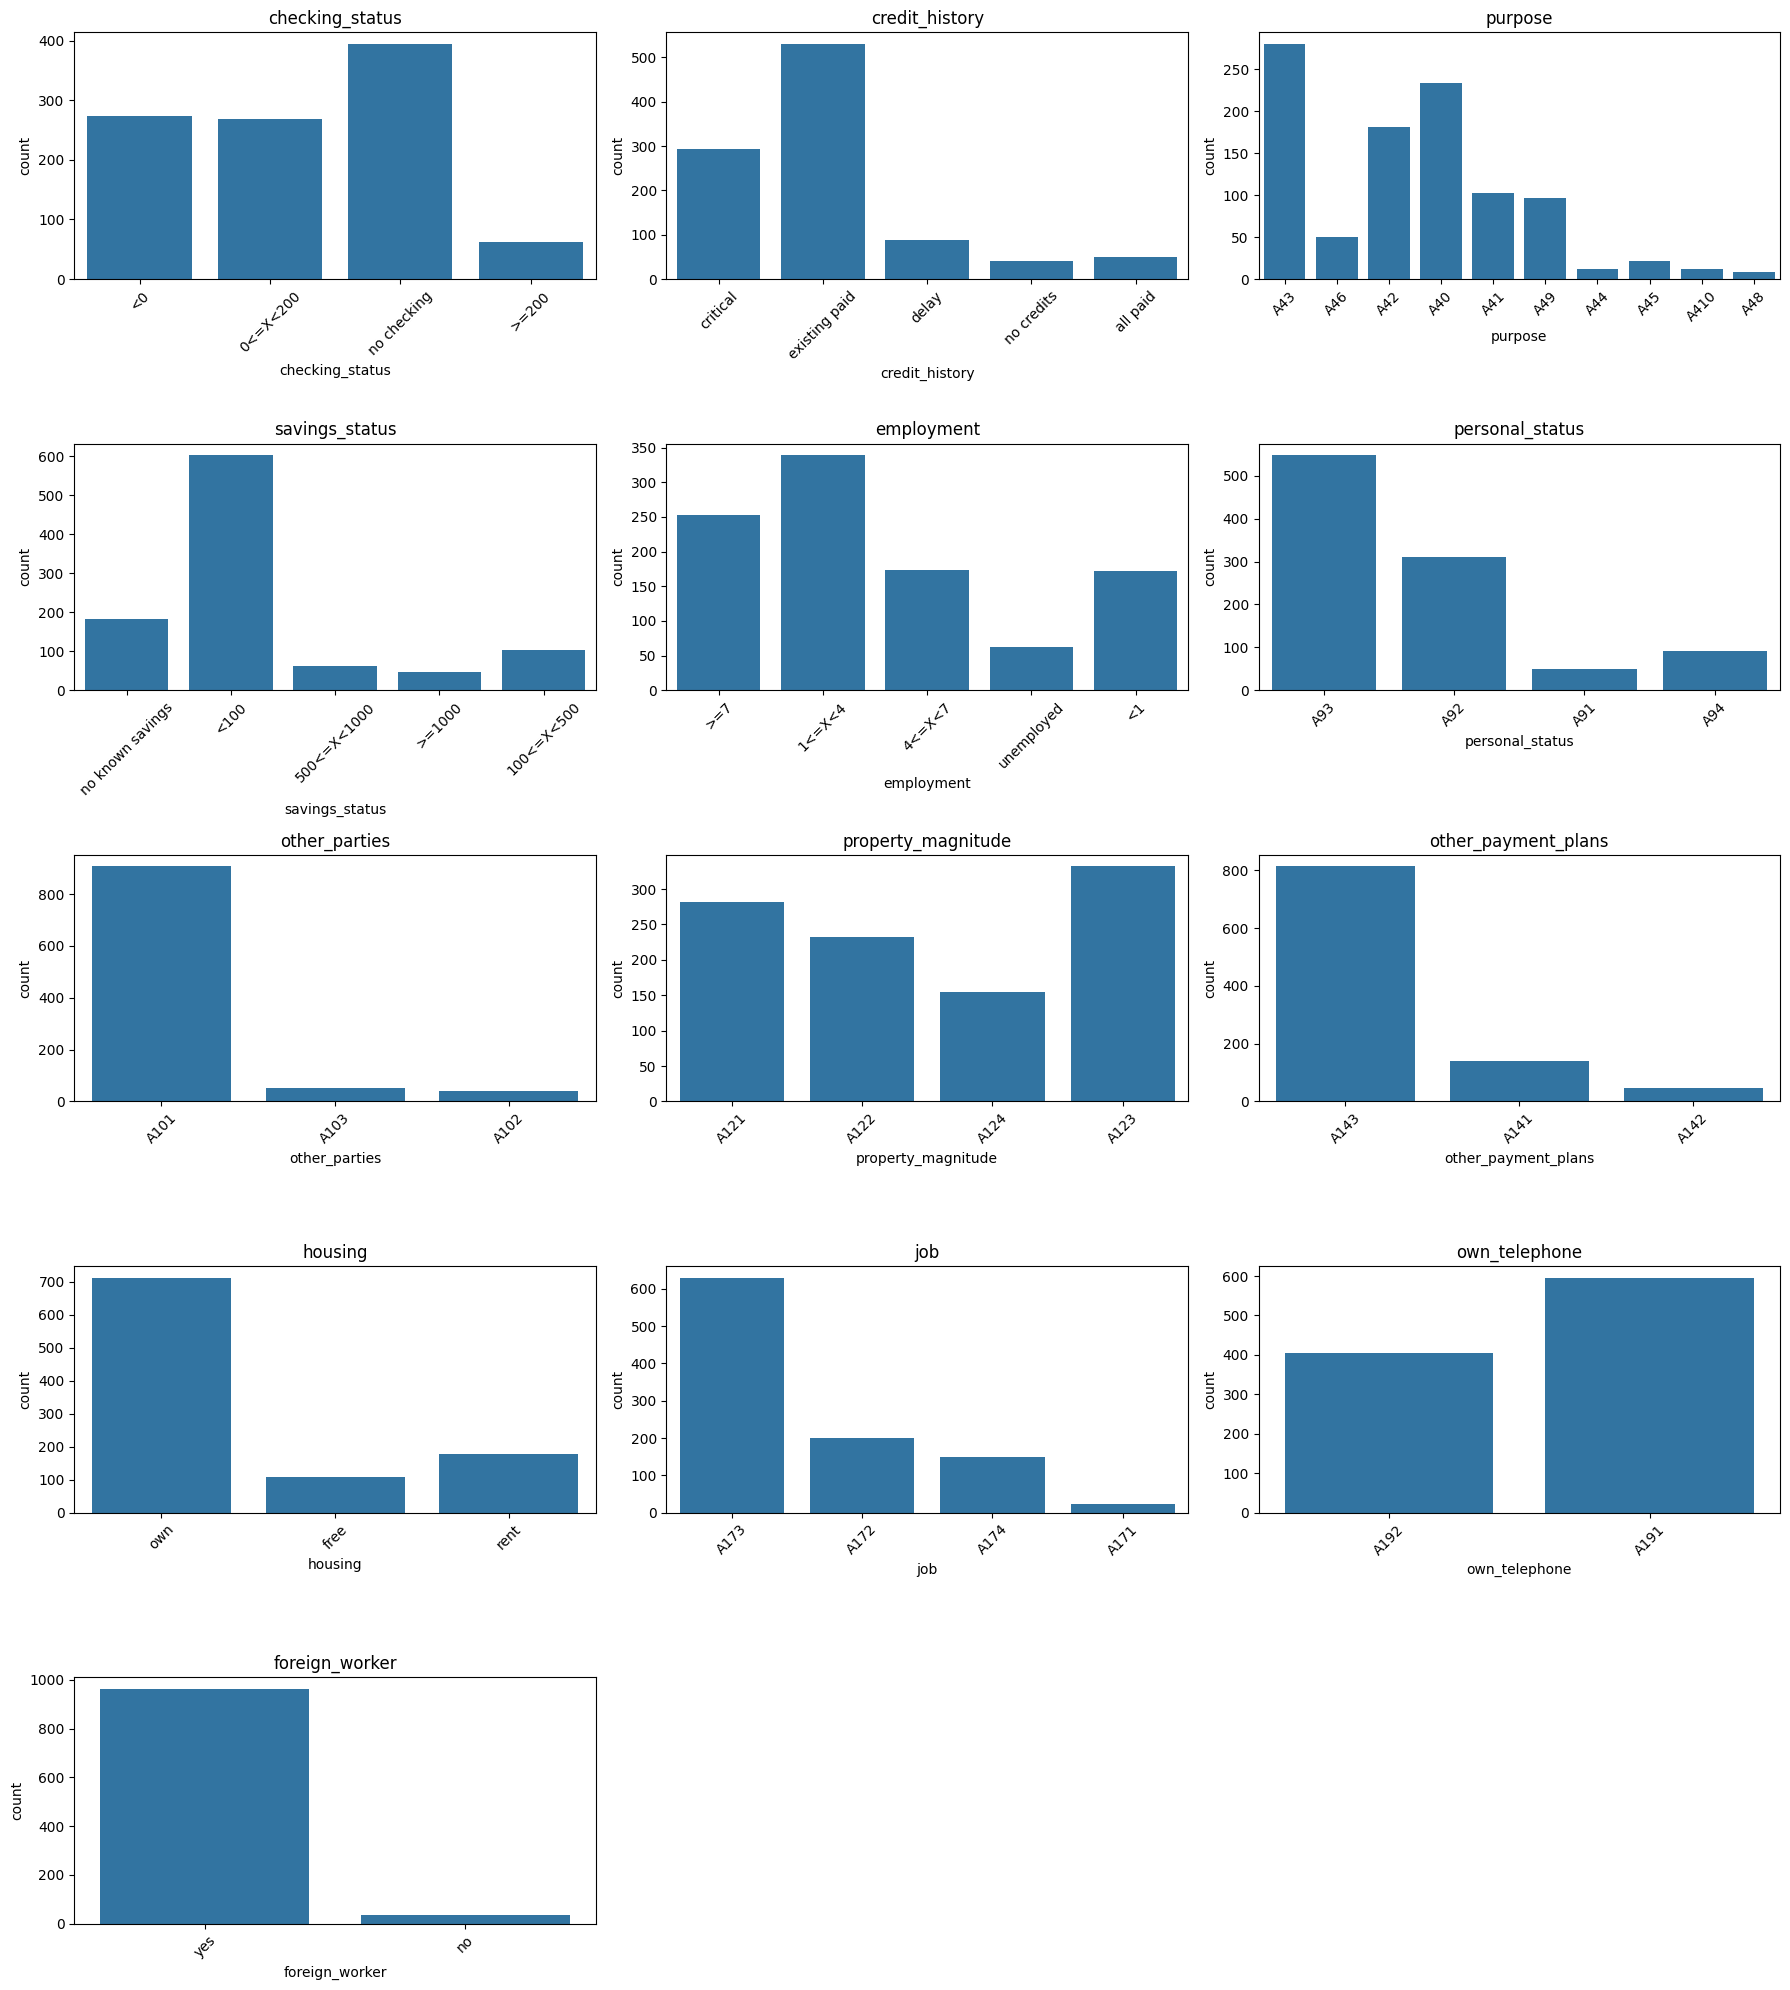

In [ ]:
n_cols = len(df_categorical.columns)
rows = 5
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(18, 20))
axes = axes.flatten()  # convertir en lista para iterar fácilmente

for i, col in enumerate(df_categorical.columns):
    sns.countplot(x=col, data=df_categorical, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

# Eliminar subplots vacíos si sobran
for j in range(i+1, rows*cols):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


<Axes: >

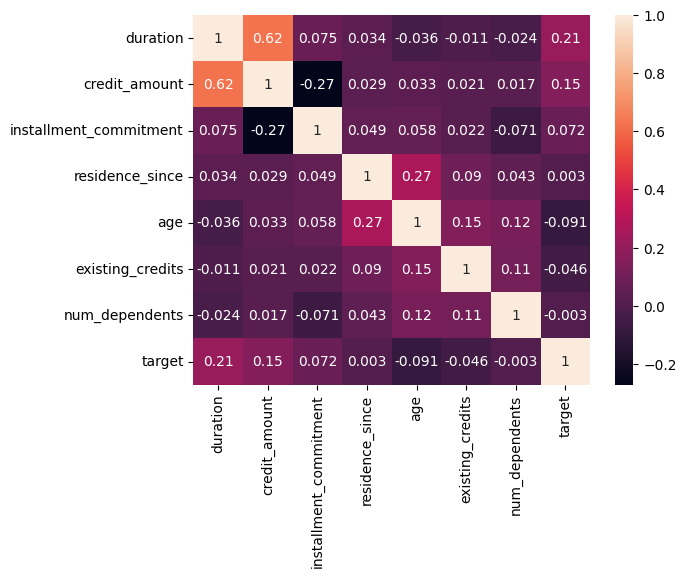

In [ ]:
sns.heatmap(df_numerical.corr(), annot=True)

###  **Feature Engineering**

Se aplicaron diversas transformaciones para enriquecer la representación de las variables originales y facilitar el aprendizaje de los modelos de clasificación. Las principales operaciones fueron:

---

#### 🔹 1. Razones y variables derivadas
- **`ratio_monto_duracion`**  
  Se creó una razón entre el monto del crédito y la duración del préstamo:  
  

$$
  \text{ratio_monto_duracion} = \frac{\text{credit_amount}}{\text{duration}}
  $$


  Esta variable captura la intensidad del crédito solicitado en relación con el plazo.

- **`es_cuenta_vacia`**  
  Variable binaria que indica si el solicitante no posee cuenta bancaria:  
  - 1 → *no checking*  
  - 0 → cualquier otro estado  

---

#### 🔹 2. Codificación ordinal basada en conocimiento del dominio
Se definieron mapeos numéricos para variables categóricas con orden implícito:

- **`employment` → `antiguedad_empleo_num`**  
  Se asignaron valores crecientes según la estabilidad laboral:
  - unemployed → 0  
  - <1 año → 1  
  - 1–4 años → 2  
  - 4–7 años → 3  
  - ≥7 años → 4  

- **`savings_status` → `savings_status2`**  
  Se codificó según el nivel de ahorro declarado:
  - no known savings → 0  
  - <100 → 1  
  - 100–500 → 2  
  - 500–1000 → 3  
  - ≥1000 → 4  

Estas transformaciones permiten que los modelos capturen la estructura ordinal de ambas variables.

---

#### 🔹 3. Variables binarias adicionales
- **`es_extranjero`**  
  Indica si el solicitante es trabajador extranjero:  
  - 1 → yes  
  - 0 → no  

---

#### 🔹 4. Codificación categórica mediante Label Encoding
Se aplicó `LabelEncoder` para transformar variables categóricas nominales en valores numéricos:

- **`credit_history` → `credit_history_encoded`**  
- **`housing` → `housing_encoded`**

Este tipo de codificación es adecuado para modelos basados en árboles, ya que no asumen relaciones lineales entre las categorías.

---

#### 🔹 5. Interacciones añadidas
Se incorporaron dos interacciones entre variables numéricas con el objetivo de capturar relaciones no lineales relevantes para el riesgo crediticio:

- **`duration_x_amount`**  
  Producto entre la duración del crédito y el monto solicitado.  
  Esta interacción refleja cómo créditos grandes a plazos largos incrementan la presión financiera del solicitante.

- **`age_x_amount`**  
  Producto entre la edad del solicitante y el monto del crédito.  
  Permite modelar diferencias en el riesgo asociado a montos elevados según el perfil etario del cliente.

Estas interacciones suelen ser especialmente útiles en modelos de ensamble como *boosting* y *bagging*, ya que facilitan la detección de patrones complejos sin necesidad de aumentar excesivamente la profundidad de los árboles.




In [ ]:
df['ratio_monto_duracion'] = df['credit_amount'] / df['duration']
df['es_cuenta_vacia'] = (df['checking_status'] == 'no checking').astype(int)
mapping = {
    'employment':{'unemployed': 0,
    '<1': 1,
    '1<=X<4': 2,
    '4<=X<7': 3,
    '>=7': 4},

    'savings_status':{'no known savings': 0,
    '<100': 1,
    '100<=X<500': 2,
    '500<=X<1000': 3,
    '>=1000': 4}
}
df['antiguedad_empleo_num'] = df['employment'].map(mapping['employment'])
df['es_extranjero'] = (df['foreign_worker'] == 'yes').astype(int)

### features que yo creo serviran
df['savings_status2'] = df['savings_status'].map(mapping['savings_status'])
le_credit = LabelEncoder()
df['credit_history_encoded'] = le_credit.fit_transform(df['credit_history'])
le_housing = LabelEncoder()
df['housing_encoded'] = le_housing.fit_transform(df['housing'])
df["duration_x_amount"] = df["duration"] * df["credit_amount"]
df["age_x_amount"] = df["age"] * df["credit_amount"]


### **Quick Model View**

A continuación se presenta una visualización rápida del desempeño de los modelos seleccionados para las variables indicadas. Este análisis preliminar permite identificar patrones generales de rendimiento y obtener una primera intuición sobre qué hiperparámetros podrían requerir ajuste en etapas posteriores de modelado.


In [ ]:
# -----------------------------
# 1. Split
# -----------------------------
X = df.drop(columns=['target'], axis=1).select_dtypes(include=['number'])
y = df['target']

# estratifica el split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -----------------------------
# 2. Modelos
# -----------------------------
rf_model = RandomForestClassifier(n_estimators=300, random_state=42)
gb_model = GradientBoostingClassifier(n_estimators=300, random_state=42)
xgb_model = xgb.XGBClassifier(n_estimators=300, random_state=42)

# -----------------------------
# 3. Entrenamiento
# -----------------------------
rf_model.fit(X_train, y_train)
gb_model.fit(X_train, y_train)
xgb_model.fit(X_train, y_train)

# -----------------------------
# 4. Predicciones
# -----------------------------
rf_preds = rf_model.predict(X_test)
gb_preds = gb_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

# -----------------------------
# 5. Métricas
# -----------------------------
def compute_metrics(model, preds):
    return {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "auc": roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
    }

rf_metrics = compute_metrics(rf_model, rf_preds)
gb_metrics = compute_metrics(gb_model, gb_preds)
xgb_metrics = compute_metrics(xgb_model, xgb_preds)

# -----------------------------
# 6. Impresión individual
# -----------------------------
def print_metrics(name, m):
    print("="*40)
    print(name)
    print(f"Accuracy : {m['accuracy']:.4f}")
    print(f"Precision: {m['precision']:.4f}")
    print(f"Recall   : {m['recall']:.4f}")
    print(f"F1 Score : {m['f1']:.4f}")
    print(f"AUC      : {m['auc']:.4f}")
    print("="*40)

print_metrics("Random Forest", rf_metrics)
print_metrics("Gradient Boosting", gb_metrics)
print_metrics("XGBoost", xgb_metrics)

# -----------------------------
# 7. Tabla comparativa final
# -----------------------------

comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "XGBoost"],
    "Accuracy": [rf_metrics["accuracy"], gb_metrics["accuracy"], xgb_metrics["accuracy"]],
    "Precision": [rf_metrics["precision"], gb_metrics["precision"], xgb_metrics["precision"]],
    "Recall": [rf_metrics["recall"], gb_metrics["recall"], xgb_metrics["recall"]],
    "F1 Score": [rf_metrics["f1"], gb_metrics["f1"], xgb_metrics["f1"]],
    "AUC": [rf_metrics["auc"], gb_metrics["auc"], xgb_metrics["auc"]],
})

print("\n\n=== COMPARACIÓN FINAL ===")
print(comparison_df)

del rf_model, gb_model, xgb_model
gc.collect()


Random Forest
Accuracy : 0.7650
Precision: 0.6383
Recall   : 0.5000
F1 Score : 0.5607
AUC      : 0.7686
Gradient Boosting
Accuracy : 0.7400
Precision: 0.5667
Recall   : 0.5667
F1 Score : 0.5667
AUC      : 0.7536
XGBoost
Accuracy : 0.7150
Precision: 0.5246
Recall   : 0.5333
F1 Score : 0.5289
AUC      : 0.7363


=== COMPARACIÓN FINAL ===
               Model  Accuracy  Precision    Recall  F1 Score       AUC
0      Random Forest     0.765   0.638298  0.500000  0.560748  0.768631
1  Gradient Boosting     0.740   0.566667  0.566667  0.566667  0.753571
2            XGBoost     0.715   0.524590  0.533333  0.528926  0.736310


37052

### Funciones para el modelado

In [ ]:
def best_RF_model(
        X_train, y_train, X_test, y_test,
        n_estimators=[100,300,500],
        max_depth=[5,10,None],
        max_features=['sqrt','log2',0.5],
        transf_X="std",
        balanceo="none",
        seed=42,
        params={
            'min_samples_split': [2,10],
            'min_samples_leaf': [1,3,5],
            'class_weight': ['balanced']
        }):

    RFC = RandomForestClassifier(
        bootstrap=True,
        random_state=seed,
        criterion='gini',
        oob_score=False,
        n_jobs=-1
    )

    registros_cv = []
    registros_test = []

    # GRIDSEARCH sobre parámetros internos
    grid = GridSearchCV(
        estimator=RFC,
        param_grid=params,
        cv=5,
        n_jobs=-1,
        scoring="roc_auc",
        refit=True,
        return_train_score=True
    )

    # BÚSQUEDA EXTERNA (n_est, depth, max_features)
    for n in n_estimators:
        for d in max_depth:
            for f in max_features:

                RFC.set_params(
                    n_estimators=n,
                    max_depth=d,
                    max_features=f
                )

                t0 = time.time()
                grid.fit(X_train, y_train)
                t1 = time.time()

                best_model = grid.best_estimator_
                best_params = grid.best_params_
                cv_mean = grid.best_score_
                cv_std = grid.cv_results_["std_test_score"][grid.best_index_]

                # AUC train
                auc_train = roc_auc_score(y_train, best_model.predict_proba(X_train)[:,1])

                # Registro tabla interna CV
                registros_cv.append({
                    "n_est": n,
                    "depth": d,
                    "max_features": f,
                    "transf_X": transf_X,
                    "balanceo": balanceo,
                    "AUC-train": auc_train,
                    "AUC-CV_mean": cv_mean,
                    "AUC-CV_std": cv_std,
                    "AUC-CV (media±std)": f"{cv_mean:.3f} ± {cv_std:.3f}",
                    "best_params": best_params
                })

                # Evaluación en test
                preds_test = best_model.predict(X_test)
                auc_test = roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1])
                f1_test = f1_score(y_test, preds_test)

                # λ-score (λ=0.5)
                lambda_score = 0.5 * auc_test + 0.5 * cv_mean

                registros_test.append({
                    "n_est": n,
                    "depth": d,
                    "max_features": f,
                    "AUC-test": auc_test,
                    "F1-test": f1_test,
                    "t (s)": t1 - t0,
                    "λ0.5-score": lambda_score
                })

    # DataFrames finales
    df_cv = pd.DataFrame(registros_cv)
    df_test = pd.DataFrame(registros_test)

    # Selección del ganador
    idx_best = df_test["λ0.5-score"].idxmax()
    df_test["Ganador"] = ""
    df_test.loc[idx_best, "Ganador"] = "✓"
    tiempo_mejor_modelo = df_test.loc[idx_best, "t (s)"]

    # Retornar el mejor modelo junto con su feature_importances_
    best_m_params = df_cv.loc[idx_best,"best_params"]
    final_model = RandomForestClassifier(random_state=seed)
    final_model.set_params(**best_m_params)
    final_model.fit(X_train, y_train)
    # plots
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    # --- MDI
    zip_df = pd.DataFrame(zip(X_train.columns,final_model.feature_importances_),
                          columns=['feature','importance']).\
                          sort_values(by='importance', ascending=False)
    axes[0].barh(zip_df.feature, zip_df.importance,color='orange')
    axes[0].set_title("Mean Decrease in Impurity (MDI)")
    axes[0].invert_yaxis()
    # --- Permutation importnce
    perm = permutation_importance(final_model, X_test, y_test, n_repeats=10,
                                  random_state=seed,n_jobs=-1)
    perm_df = pd.DataFrame({'feature':X_train.columns,
                            'importance':perm.importances_mean}).\
                            sort_values(by='importance', ascending=False)
    axes[1].barh(perm_df.feature, perm_df.importance,color='steelblue')
    axes[1].set_title("Permutation Importance")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.show()


    return df_cv, df_test, final_model, tiempo_mejor_modelo


def best_boosting_model(
        X_train, y_train, X_test, y_test,
        n_estimators=[100, 300],
        learning_rate=[0.01, 0.1],
        max_depth=[3, 5],
        subsample=[0.7, 1.0],
        transf_X="std",
        balanceo="none",
        seed=42,
        params_gdb={
            "min_samples_split": [2, 10],
            "min_samples_leaf": [1, 3]
        },
        params_xgb={
            "gamma": [0, 1],
            "reg_lambda": [1, 5]
        }
    ):

    # ---------------------------
    # 1. Inicializar registros
    # ---------------------------
    registros_cv_gdb = []
    registros_test_gdb = []
    registros_cv_xgb = []
    registros_test_xgb = []

    # ---------------------------
    # 2. GRIDSEARCH para GDB
    # ---------------------------
    grid_gdb = GridSearchCV(
        estimator=GradientBoostingClassifier(random_state=seed),
        param_grid=params_gdb,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )

    # ---------------------------
    # 3. GRIDSEARCH para XGB
    # ---------------------------
    grid_xgb = GridSearchCV(
        estimator=xgb.XGBClassifier(
            random_state=seed,
            eval_metric="logloss",
            n_jobs=-1,
            tree_method="hist"
        ),
        param_grid=params_xgb,
        cv=5,
        scoring="roc_auc",
        n_jobs=-1,
        refit=True,
        return_train_score=True
    )

    # ---------------------------
    # 4. Búsqueda externa
    # ---------------------------
    for n in n_estimators:
        for lr in learning_rate:
            for d in max_depth:
                for ss in subsample:

                    # ============================
                    # GRADIENT BOOSTING
                    # ============================
                    gdb = GradientBoostingClassifier(
                        n_estimators=n,
                        learning_rate=lr,
                        max_depth=d,
                        subsample=ss,
                        random_state=seed
                    )

                    t0 = time.time()
                    grid_gdb.estimator = gdb
                    grid_gdb.fit(X_train, y_train)
                    t1 = time.time()

                    best_gdb = grid_gdb.best_estimator_
                    cv_mean = grid_gdb.best_score_
                    cv_std = grid_gdb.cv_results_["std_test_score"][grid_gdb.best_index_]
                    auc_train = roc_auc_score(y_train, best_gdb.predict_proba(X_train)[:, 1])

                    # staged AUC corregido: staged_predict_proba sobre test árbol a árbol
                    staged_train = []
                    staged_val = []
                    for y_pred_train, y_pred_val in zip(
                        best_gdb.staged_predict_proba(X_train),
                        best_gdb.staged_predict_proba(X_test)
                    ):
                        staged_train.append(roc_auc_score(y_train, y_pred_train[:, 1]))
                        staged_val.append(roc_auc_score(y_test,  y_pred_val[:, 1]))

                    registros_cv_gdb.append({
                        "n_est": n,
                        "lr": lr,
                        "depth": d,
                        "subsample": ss,
                        "transf_X": transf_X,
                        "balanceo": balanceo,
                        "AUC-train": auc_train,
                        "AUC-CV_mean": cv_mean,
                        "AUC-CV_std": cv_std,
                        "AUC-CV (media±std)": f"{cv_mean:.3f} ± {cv_std:.3f}",
                        "best_params": grid_gdb.best_params_,
                        "staged_train": staged_train,
                        "staged_val": staged_val,
                        "model": best_gdb
                    })

                    preds_test = best_gdb.predict(X_test)
                    auc_test = roc_auc_score(y_test, best_gdb.predict_proba(X_test)[:, 1])
                    f1_test = f1_score(y_test, preds_test)
                    lambda_score = 0.5 * auc_test + 0.5 * cv_mean

                    registros_test_gdb.append({
                        "n_est": n,
                        "lr": lr,
                        "depth": d,
                        "subsample": ss,
                        "AUC-test": auc_test,
                        "F1-test": f1_test,
                        "t (s)": t1 - t0,
                        "λ0.5-score": lambda_score
                    })

                    # ============================
                    # XGBOOST
                    # ============================
                    xgb_model = xgb.XGBClassifier(
                        n_estimators=n,
                        learning_rate=lr,
                        max_depth=d,
                        subsample=ss,
                        random_state=seed,
                        eval_metric="logloss",
                        n_jobs=-1,
                        tree_method="hist"
                    )

                    t0 = time.time()
                    grid_xgb.estimator = xgb_model
                    grid_xgb.fit(X_train, y_train)
                    t1 = time.time()

                    best_xgb = grid_xgb.best_estimator_
                    cv_mean = grid_xgb.best_score_
                    cv_std = grid_xgb.cv_results_["std_test_score"][grid_xgb.best_index_]
                    auc_train = roc_auc_score(y_train, best_xgb.predict_proba(X_train)[:, 1])

                    # staged AUC via booster iteration_range
                    staged_train = []
                    staged_val = []

                    booster = best_xgb.get_booster()
                    dmat_train = xgb.DMatrix(X_train)
                    dmat_test  = xgb.DMatrix(X_test)

                    for i in range(1, n + 1):
                        p_train = booster.predict(dmat_train, iteration_range=(0, i))
                        p_test  = booster.predict(dmat_test,  iteration_range=(0, i))
                        staged_train.append(roc_auc_score(y_train, p_train))
                        staged_val.append(roc_auc_score(y_test,  p_test))

                    registros_cv_xgb.append({
                        "n_est": n,
                        "lr": lr,
                        "depth": d,
                        "subsample": ss,
                        "transf_X": transf_X,
                        "balanceo": balanceo,
                        "AUC-train": auc_train,
                        "AUC-CV_mean": cv_mean,
                        "AUC-CV_std": cv_std,
                        "AUC-CV (media±std)": f"{cv_mean:.3f} ± {cv_std:.3f}",
                        "best_params": grid_xgb.best_params_,
                        "staged_train": staged_train,
                        "staged_val": staged_val,
                        "model": best_xgb
                    })

                    preds_test = best_xgb.predict(X_test)
                    auc_test = roc_auc_score(y_test, best_xgb.predict_proba(X_test)[:, 1])
                    f1_test = f1_score(y_test, preds_test)
                    lambda_score = 0.5 * auc_test + 0.5 * cv_mean

                    registros_test_xgb.append({
                        "n_est": n,
                        "lr": lr,
                        "depth": d,
                        "subsample": ss,
                        "AUC-test": auc_test,
                        "F1-test": f1_test,
                        "t (s)": t1 - t0,
                        "λ0.5-score": lambda_score
                    })

    # ---------------------------
    # 5. DataFrames finales
    # ---------------------------
    df_cv_gdb = pd.DataFrame(registros_cv_gdb)
    df_test_gdb = pd.DataFrame(registros_test_gdb)
    df_cv_xgb = pd.DataFrame(registros_cv_xgb)
    df_test_xgb = pd.DataFrame(registros_test_xgb)

    idx_gdb = df_test_gdb["λ0.5-score"].idxmax()
    idx_xgb = df_test_xgb["λ0.5-score"].idxmax()

    best_gdb_model = df_cv_gdb.loc[idx_gdb, "model"]
    best_xgb_model = df_cv_xgb.loc[idx_xgb, "model"]

    df_test_gdb["Ganador"] = ""
    df_test_gdb.loc[idx_gdb, "Ganador"] = "✓"
    df_test_xgb["Ganador"] = ""
    df_test_xgb.loc[idx_xgb, "Ganador"] = "✓"

    tiempo_mejor_modelo_gb = df_test_gdb.loc[idx_gdb, "t (s)"]
    tiempo_mejor_modelo_xgb = df_test_xgb.loc[idx_xgb, "t (s)"]

    # ---------------------------
    # 6. Figura única con ambos staged loss
    # ---------------------------
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # --- subplot GDB ---
    axes[0].plot(df_cv_gdb.loc[idx_gdb, "staged_train"], label="Train AUC")
    axes[0].plot(df_cv_gdb.loc[idx_gdb, "staged_val"],   label="Validation AUC")
    axes[0].set_title("Staged AUC - Mejor GradientBoosting")
    axes[0].set_xlabel("Número de árboles")
    axes[0].set_ylabel("AUC")
    axes[0].legend()

    # --- subplot XGB ---
    axes[1].plot(df_cv_xgb.loc[idx_xgb, "staged_train"], label="Train AUC")
    axes[1].plot(df_cv_xgb.loc[idx_xgb, "staged_val"],   label="Validation AUC")
    axes[1].set_title("Staged AUC - Mejor XGBoost")
    axes[1].set_xlabel("Número de árboles")
    axes[1].set_ylabel("AUC")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return df_cv_gdb, df_test_gdb, df_cv_xgb, df_test_xgb, best_gdb_model, best_xgb_model, (tiempo_mejor_modelo_gb,tiempo_mejor_modelo_xgb)


def stacking_model(
        X_train, y_train, X_test, y_test,
        best_rf,       # modelo Random Forest ya entrenado
        best_xgb,      # modelo XGBoost ya entrenado
        best_gdb,      # modelo GradientBoosting ya entrenado
        tiempos,
        cv_meta=5,
        seed=42
    ):
    """
    Implementa un StackingClassifier de dos niveles:
      - Nivel 0: Random Forest, XGBoost, GradientBoosting
      - Nivel 1: LogisticRegressionCV (meta-learner con CV interna)

    Retorna:
        stack_model  : StackingClassifier entrenado
        df_comparacion: DataFrame comparando base learners vs stacking
    """

    # ---------------------------
    # 1. Definir base learners
    #    se pasan con clone implícito dentro de StackingClassifier
    # ---------------------------
    rf_base  = RandomForestClassifier(**best_rf.get_params())
    xgb_base = xgb.XGBClassifier(**best_xgb.get_params())
    gdb_base = GradientBoostingClassifier(**best_gdb.get_params())

    base_learners = [
    ("random_forest", rf_base),
    ("xgboost", xgb_base),
    ("gradient_boosting", gdb_base)
    ]


    # ---------------------------
    # 2. Meta-learner
    # ---------------------------
    meta_learner = LogisticRegressionCV(
        cv=cv_meta,
        scoring="roc_auc",
        max_iter=1000,
        random_state=seed,
        class_weight="balanced",
        n_jobs=-1
    )

    # ---------------------------
    # 3. StackingClassifier
    #    passthrough=True: el meta-learner recibe también
    #    las features originales además de las predicciones
    # ---------------------------
    stack = StackingClassifier(
        estimators=base_learners,
        final_estimator=meta_learner,
        cv=cv_meta,
        stack_method="predict_proba",   # usa probabilidades como input del meta-learner
        passthrough=False,
        n_jobs=-1
    )

    # ---------------------------
    # 4. Entrenar stacking
    # ---------------------------
    t0 = time.time()
    stack.fit(X_train, y_train)
    t1 = time.time()

    # ---------------------------
    # 5. Métricas stacking
    # ---------------------------
    preds_stack      = stack.predict(X_test)
    probas_stack     = stack.predict_proba(X_test)[:, 1]
    auc_test_stack   = roc_auc_score(y_test, probas_stack)
    f1_test_stack    = f1_score(y_test, preds_stack)

    cv_scores_stack  = cross_val_score(stack, X_train, y_train,
                                       cv=cv_meta, scoring="roc_auc", n_jobs=-1)
    auc_cv_stack     = cv_scores_stack.mean()
    std_cv_stack     = cv_scores_stack.std()
    lambda_stack     = 0.5 * auc_test_stack + 0.5 * auc_cv_stack

    # ---------------------------
    # 6. Métricas base learners (para comparación)
    # ---------------------------
    registros = []


    for nombre, modelo, tiempo in [("Random Forest", best_rf, tiempos[0]),
                           ("GradientBoost", best_gdb, tiempos[1][0]),
                           ("XGBoost",       best_xgb, tiempos[1][0])
                           ]:

        preds   = modelo.predict(X_test)
        probas  = modelo.predict_proba(X_test)[:, 1]
        auc_t   = roc_auc_score(y_test, probas)
        f1_t    = f1_score(y_test, preds)

        cv_sc   = cross_val_score(modelo, X_train, y_train,
                                  cv=cv_meta, scoring="roc_auc", n_jobs=-1)
        auc_cv  = cv_sc.mean()
        std_cv  = cv_sc.std()
        lam     = 0.5 * auc_t + 0.5 * auc_cv

        registros.append({
            "Modelo":               nombre,
            "AUC-test":             round(auc_t,  4),
            "F1-test":              round(f1_t,   4),
            "AUC-CV (mean)":        round(auc_cv, 4),
            "AUC-CV (std)":         round(std_cv, 4),
            "AUC-CV (media±std)":   f"{auc_cv:.3f} ± {std_cv:.3f}",
            "λ0.5-score":           round(lam,    4),
            "t (s)":                tiempo
        })

    # Agregar stacking
    registros.append({
        "Modelo":               "Stacking",
        "AUC-test":             round(auc_test_stack,  4),
        "F1-test":              round(f1_test_stack,   4),
        "AUC-CV (mean)":        round(auc_cv_stack,    4),
        "AUC-CV (std)":         round(std_cv_stack,    4),
        "AUC-CV (media±std)":   f"{auc_cv_stack:.3f} ± {std_cv_stack:.3f}",
        "λ0.5-score":           round(lambda_stack,    4),
        "t (s)":                round(t1 - t0,         2)
    })

    df_comparacion = pd.DataFrame(registros).set_index("Modelo")

    # ---------------------------
    # 7. Gráfico comparativo
    # ---------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    modelos   = df_comparacion.index.tolist()
    colores   = ["steelblue", "darkorange", "seagreen", "crimson"]
    metricas  = ["AUC-test", "F1-test", "λ0.5-score"]
    titulos   = ["AUC — Test", "F1 — Test", "λ0.5-score (AUC-test + AUC-CV)"]

    for ax, metrica, titulo in zip(axes, metricas, titulos):
        valores = df_comparacion[metrica].values
        barras  = ax.bar(modelos, valores, color=colores, edgecolor="white", width=0.5)
        ax.set_title(titulo, fontsize=11)
        ax.set_ylim(min(valores) * 0.97, max(valores) * 1.02)
        ax.set_ylabel(metrica)
        ax.tick_params(axis="x", rotation=15)
        for bar, val in zip(barras, valores):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.001,
                    f"{val:.4f}", ha="center", va="bottom", fontsize=9)

    plt.suptitle("Comparación: Base Learners vs Stacking", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

    return stack, df_comparacion

#### Mejores Modelos:

###### Mejor RandomForest

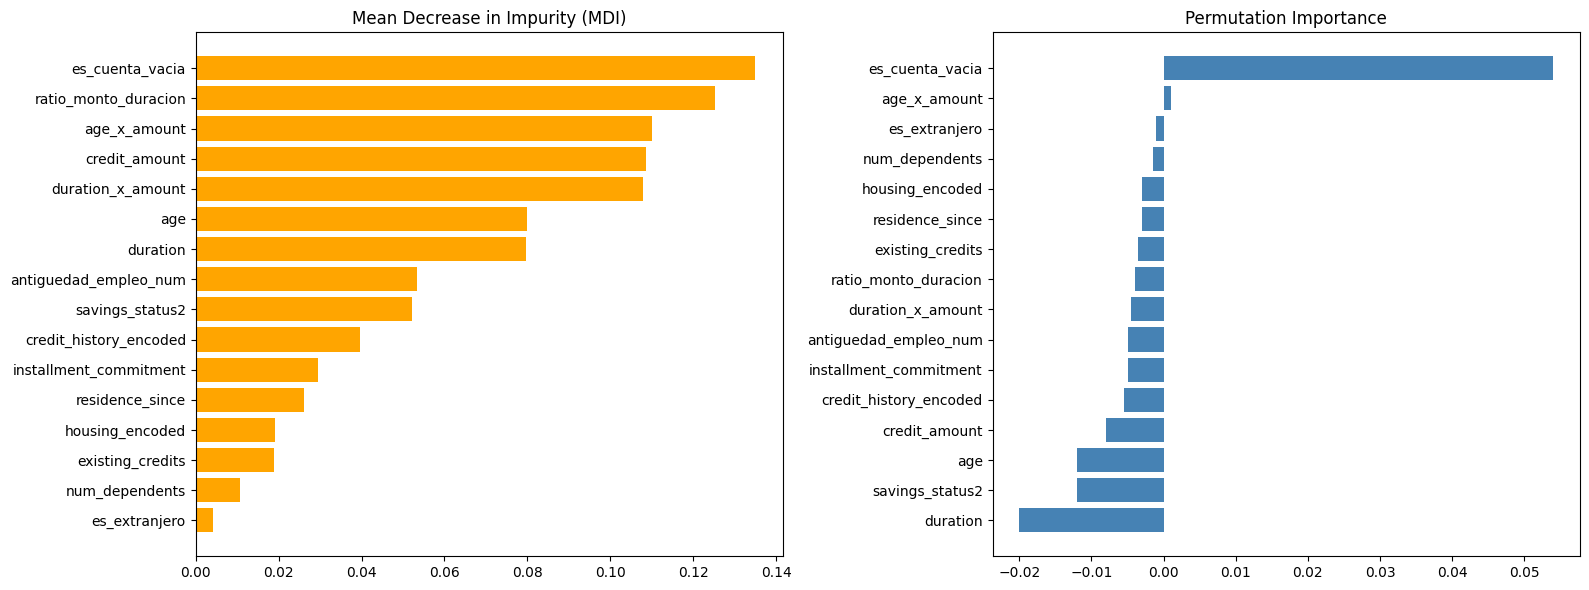

In [ ]:
df_cv_RF,df_test_RF,best_rf,t_rf= best_RF_model(X_train, y_train, X_test, y_test)

**Reporte de importancia de variables (MDI+permutation importance)**

**MDI** (mean-decrease-in-impurity) refleja cuánto reduce la impureza cada variable dentro de los árboles del modelo. Tiende a favorecer variables con alta cardinalidad o muchas categorías, y distribuye importancia entre variables correlacionadas. -> mide importancia estructural.

**Permutation Importance** mide la pérdida real de desempeño al desordenar una variable. Es más fiel al impacto real en el modelo, pero puede subestimar variables correlacionadas porque otras pueden suplir su información. -> mide importancia funcional.

Cuando ambas métricas difieren, normalmente se debe a correlación entre variables, cardinalidad alta o ruido. En general, MDI puede sobreestimar importancia, mientras que Permutation Importance refleja mejor la contribución real al desempeño.

Para este conjunto de datos tenemos que difieren en su interpretación del modelo, es decir, cada métrica de importancia tiene distinta relevancia para casi todas las variables consideradas.

Por un lado, era claro que el hecho de incluir variables derivadas como `ratio_monto_duracion` iban a tomar una importancia similar a sus predecesoras. Para MDI estas variables son las que lideraron a un aumento en la pureza de los nodos.

Del otro lado, `es_cuenta_vacia` toma la mayor importancia pues al permutar esta variable, el desempeño del modelo cae mayormente. Por lo que su impacto en la predicción es mayor y el modelo tiene gran dependencia en esta.

**Varianza del ensamble de árboles correlacionados**

Sea un ensamble de \(B\) árboles $f_b$  i.d., cada uno con varianza ($σ^2$) y correlación (ρ).  
El ensamble es el promedio:
$$
\bar{f} = \frac{1}{B}\sum_{b=1}^B f_b
$$

Queremos demostrar:
$$
\mathrm{Var}(\bar{f}) = \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2
$$

---

$$
\mathrm{Var}(\bar{f})
= \mathrm{Var}\left(\frac{1}{B}\sum_{b=1}^B f_b\right)
= \frac{1}{B^2}\,\mathrm{Var}\left(\sum_{b=1}^B f_b\right)
$$

Y:

$$
\mathrm{Var}\left(\sum_{b=1}^B f_b\right)
= \sum_{b=1}^B \mathrm{Var}(f_b)
+ \sum_{b\neq b'} \mathrm{Cov}(f_b, f_{b'})
$$

---
entonces sustituyendo tenemos:
$$
\sum_{b=1}^B \mathrm{Var}(f_b) = B\sigma^2,
$$
ahora recordemos que la correlacion es el cociente de la covarianza entre la raiz cuadrada del producto de las varianzas respectivamente, pero como son i.d. tienen la misma $σ^2$ y entonces:
$$
\mathrm{Cov}(f_b, f_{b'}) = \rho\sigma^2
$$
así:
$$
\sum_{b\neq b'} \mathrm{Cov}(f_b, f_{b'}) = B(B-1)\rho\sigma^2
$$

pues el número de pares ordenados es B(B-1)

---
Con lo anterior ya mencionado llegamos a que:
$$
\mathrm{Var}\left(\sum_{b=1}^B f_b\right)
= B\sigma^2 + B(B-1)\rho\sigma^2
$$

$$
⇒ \mathrm{Var}(\bar{f})
= \frac{1}{B^2}\left[B\sigma^2 + B(B-1)\rho\sigma^2\right]
$$

Factorizamos y despues ordenamos a ρ:
$$
\mathrm{Var}(\bar{f})
= \frac{\sigma^2}{B}\left[1 + (B-1)\rho\right] \\
⇒ \mathrm{Var}(\bar{f})
= \frac{\sigma^2}{B}\left[B\rho + (1-\rho)\right]
$$
Por lo tanto:

$$
\mathrm{Var}(\bar{f})
= \rho\sigma^2 + \frac{1-\rho}{B}\sigma^2
$$

---

**Interpretación**

- $\rho σ^2$: parte de la varianza que **no disminuye** aunque aumentes \(B\).  
- $(\frac{1-\rho}{B}\sigma^2)$: parte que **sí baja** al aumentar \(B\).

Por eso, en Random Forests, **reducir la correlación ($\rho$)** por ejemplo, bajando `max_features` es más efectivo que simplemente aumentar el número de árboles \(B\).
Reducir ($\rho$) disminuye directamente el límite inferior de la varianza del ensamble, mientras que aumentar \(B\) solo reduce el segundo término, que se vuelve pequeño rápidamente.


In [ ]:
print('\nMuestra de entrenamiento de modelos para RandomForest(): ...')
display(df_cv_RF.iloc[[0,5,10,18,20,25],:])
print('='*60)
print('\nMuestra de test de modelos para RandomForest(): ...')
display(df_test_RF.iloc[[1,4,18,7,9],:])


Muestra de entrenamiento de modelos para RandomForest(): ...


,n_est,depth,max_features,transf_X,balanceo,AUC-train,AUC-CV_mean,AUC-CV_std,AUC-CV (media±std),best_params
0,100,5.0,sqrt,std,none,0.896964,0.770275,0.020638,0.770 ± 0.021,"{'class_weight': 'balanced', 'min_samples_leaf..."
5,100,10.0,0.5,std,none,0.999211,0.763951,0.034103,0.764 ± 0.034,"{'class_weight': 'balanced', 'min_samples_leaf..."
10,300,5.0,log2,std,none,0.897359,0.770982,0.018483,0.771 ± 0.018,"{'class_weight': 'balanced', 'min_samples_leaf..."
18,500,5.0,sqrt,std,none,0.896823,0.771875,0.015481,0.772 ± 0.015,"{'class_weight': 'balanced', 'min_samples_leaf..."
20,500,5.0,0.5,std,none,0.892917,0.767634,0.022689,0.768 ± 0.023,"{'class_weight': 'balanced', 'min_samples_leaf..."
25,500,NaN,log2,std,none,0.993452,0.765625,0.026055,0.766 ± 0.026,"{'class_weight': 'balanced', 'min_samples_leaf..."



Muestra de test de modelos para RandomForest(): ...


,n_est,depth,max_features,AUC-test,F1-test,t (s),λ0.5-score,Ganador
1,100,5.0,log2,0.799524,0.629371,7.385366,0.784900,
4,100,10.0,log2,0.788333,0.593750,8.939353,0.777593,
18,500,5.0,sqrt,0.801190,0.606897,34.250698,0.786533,✓
7,100,NaN,log2,0.768452,0.603175,8.946641,0.768136,
9,300,5.0,sqrt,0.798690,0.602740,28.031935,0.784836,


##### Mejor Boosting Model

**Gradient Boosting como Descenso en Gradiente Funcional**

Sea un problema de aprendizaje supervisado con datos $\{(x_i, y_i)\}_{i=1}^n$. Buscamos construir un modelo aditivo de la forma:

$$F_m(x) = F_{m-1}(x) + \nu \, h_m(x)$$

donde $F_m$ es el modelo en la iteración $m$, $\nu$ es la tasa de aprendizaje (shrinkage) y $h_m$ es el nuevo aprendiz débil o "weak learner" (por ejemplo, un árbol de decisión).

Definimos la función de pérdida empírica total sobre el conjunto de entrenamiento:

$$\mathcal{L}(F) = \sum_{i=1}^n L(y_i, F(x_i))$$

La idea central de **Gradient Boosting** es interpretar el modelo $F$ no como un conjunto de parámetros, sino como un elemento en un espacio de funciones, y aplicar **descenso en gradiente funcional** para minimizar $\mathcal{L}(F)$.

---

#### 1. El gradiente funcional

Si tratamos las predicciones del modelo en los datos de entrenamiento como un vector de $n$ dimensiones $[F(x_1), F(x_2), \dots, F(x_n)]$, el gradiente de la pérdida empírica $\mathcal{L}$ respecto a las predicciones evaluadas en cada punto $x_i$ es simplemente la derivada parcial:

$$\frac{\partial \mathcal{L}}{\partial F(x_i)} = \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}$$

En la iteración $m$, evaluamos este gradiente usando las predicciones de nuestro modelo actual $F_{m-1}$:

$$g_{im} = \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F = F_{m-1}(x)}$$

---

#### 2. La necesidad de una proyección (El paso de descenso)

En el algoritmo tradicional de descenso de gradiente, actualizaríamos nuestras estimaciones restando el gradiente multiplicado por un tamaño de paso. En el espacio funcional, eso equivaldría a:

$$F_m(x_i) = F_{m-1}(x_i) - \nu \, g_{im}$$

**El problema:** Esta actualización solo nos da los nuevos valores óptimos para los **puntos de entrenamiento** $x_i$. No nos proporciona un modelo $F_m(x)$ definido para datos no vistos (no generaliza).

Para solucionar esto, no podemos movernos en cualquier dirección funcional arbitraria; debemos restringir nuestro paso a la familia de funciones representables por nuestro "weak learner" (espacio $\mathcal{H}$, como los árboles de regresión). Por lo tanto, buscamos una función $h_m(x) \in \mathcal{H}$ que sea lo más paralela posible al **negativo del gradiente**.

---

#### 3. Ajustando pseudo-residuales (Proyección)

Para encontrar esa función $h_m(x)$, definimos los **pseudo-residuales** (el negativo del gradiente) en la iteración $m$ para cada observación:

$$r_{im} = - g_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F = F_{m-1}(x)}$$

Para proyectar este vector de pseudo-residuales sobre nuestro espacio de árboles $\mathcal{H}$, ajustamos el nuevo árbol $h_m$ para que sus predicciones $h(x_i)$ se acerquen lo más posible a $r_{im}$. Esto se hace minimizando el Error Cuadrático Medio (MSE), independientemente de cuál sea la función de pérdida original $L$:

$$h_m = \arg\min_{h \in \mathcal{H}} \sum_{i=1}^n (r_{im} - h(x_i))^2$$

Una vez entrenado este árbol, el paso de actualización final se escribe como:

$$F_m(x) = F_{m-1}(x) + \nu \, h_m(x)$$

---

### Conclusión

Gradient Boosting es un método de **descenso en gradiente funcional** porque optimiza la pérdida $\mathcal{L}(F)$ iterativamente en el espacio de funciones.

Debido a que no podemos evaluar el gradiente en puntos que no están en nuestra muestra, en cada iteración $m$ entrenamos un árbol $h_m$ utilizando mínimos cuadrados ordinarios para aproximar los **pseudo-residuales**:

$$r_{im} = - \left[ \frac{\partial L(y_i, F(x_i))}{\partial F(x_i)} \right]_{F = F_{m-1}(x)}$$

En otras palabras, el árbol no ajusta los errores clásicos $(y - \hat{y})$ (a menos que usemos la pérdida cuadrática, donde coinciden), sino que **ajusta el negativo del gradiente** de la función de pérdida evaluada en las predicciones actuales, permitiendo que el modelo generalice la dirección de máximo descenso a nuevos datos.

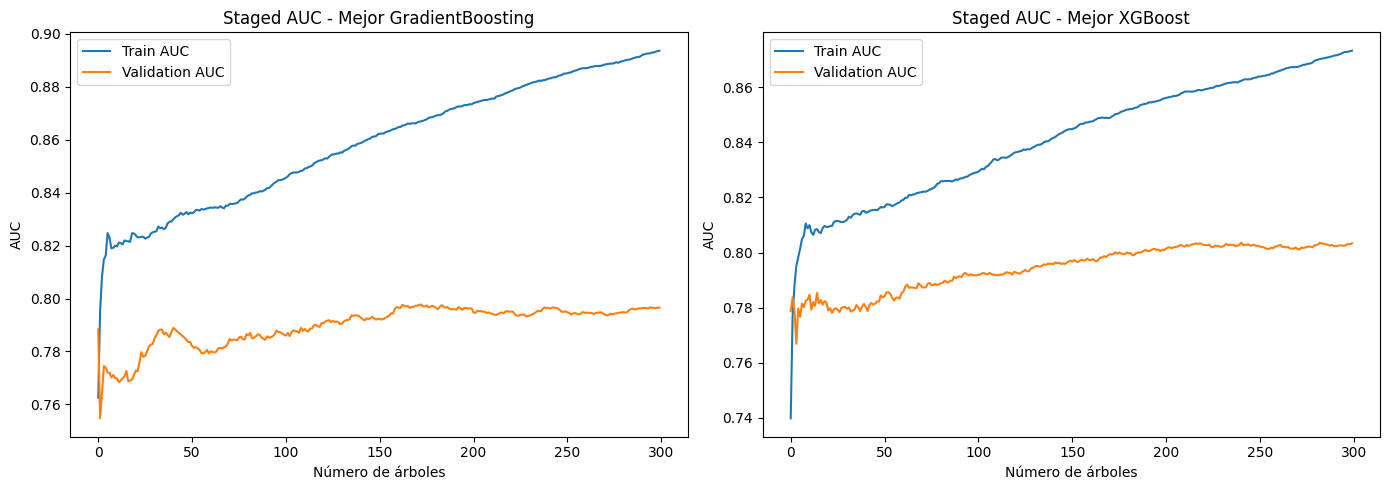

In [ ]:
df_cv_gdb, df_test_gdb, df_cv_xgb, df_test_xgb, best_gdb, best_xgb, tiempos= best_boosting_model(X_train, y_train, X_test, y_test)

In [ ]:
# df_cv_gdb, df_test_gdb, df_cv_xgb, df_test_xgb

In [ ]:
df_test_xgb

,n_est,lr,depth,subsample,AUC-test,F1-test,t (s),λ0.5-score,Ganador
0,100,0.01,3,0.7,0.791667,0.153846,2.023159,0.774684,
1,100,0.01,3,1.0,0.772917,0.000000,1.100712,0.762230,
2,100,0.01,5,0.7,0.792976,0.400000,1.727966,0.778612,
3,100,0.01,5,1.0,0.784405,0.301370,1.779301,0.763826,
4,100,0.10,3,0.7,0.798452,0.625000,1.062868,0.783899,
5,100,0.10,3,1.0,0.790476,0.605505,0.980984,0.778441,
6,100,0.10,5,0.7,0.786786,0.608696,2.987103,0.776224,
7,100,0.10,5,1.0,0.766071,0.553571,1.472319,0.763356,
8,300,0.01,3,0.7,0.803333,0.574257,2.551962,0.787195,✓
9,300,0.01,3,1.0,0.787143,0.562500,2.510998,0.772366,


In [ ]:
print('\nMuestra de entrenamiento de modelos para GradientBoosting(): ...')
display(df_cv_gdb.iloc[[0,2,8,10,15],:-3])
print('='*60)
print('\nMuestra de entrenamiento de modelos para XGBoost(): ...')
display(df_cv_xgb.iloc[::5,:-3])
print('='*60)
print('\nMuestra de test de modelos para GradientBoosting(): ...')
display(df_test_gdb.iloc[[0,2,8,10,15],:])
print('\nMuestra de test de modelos para XGBoost(): ...')
display(df_test_xgb.iloc[::5,:])


Muestra de entrenamiento de modelos para GradientBoosting(): ...


,n_est,lr,depth,subsample,transf_X,balanceo,AUC-train,AUC-CV_mean,AUC-CV_std,AUC-CV (media±std),best_params
0,100,0.01,3,0.7,std,none,0.845167,0.759394,0.014197,0.759 ± 0.014,"{'min_samples_leaf': 1, 'min_samples_split': 2}"
2,100,0.01,5,0.7,std,none,0.920238,0.768192,0.017745,0.768 ± 0.018,"{'min_samples_leaf': 1, 'min_samples_split': 10}"
8,300,0.01,3,0.7,std,none,0.893564,0.770722,0.015823,0.771 ± 0.016,"{'min_samples_leaf': 1, 'min_samples_split': 2}"
10,300,0.01,5,0.7,std,none,0.973214,0.775000,0.017984,0.775 ± 0.018,"{'min_samples_leaf': 1, 'min_samples_split': 10}"
15,300,0.10,5,1.0,std,none,1.000000,0.753646,0.023243,0.754 ± 0.023,"{'min_samples_leaf': 1, 'min_samples_split': 2}"



Muestra de entrenamiento de modelos para XGBoost(): ...


,n_est,lr,depth,subsample,transf_X,balanceo,AUC-train,AUC-CV_mean,AUC-CV_std,AUC-CV (media±std),best_params
0,100,0.01,3,0.7,std,none,0.829066,0.757701,0.016507,0.758 ± 0.017,"{'gamma': 1, 'reg_lambda': 1}"
5,100,0.10,3,1.0,std,none,0.907493,0.766406,0.020578,0.766 ± 0.021,"{'gamma': 0, 'reg_lambda': 5}"
10,300,0.01,5,0.7,std,none,0.941793,0.772098,0.020609,0.772 ± 0.021,"{'gamma': 1, 'reg_lambda': 1}"
15,300,0.10,5,1.0,std,none,0.926071,0.754129,0.021459,0.754 ± 0.021,"{'gamma': 1, 'reg_lambda': 5}"



Muestra de test de modelos para GradientBoosting(): ...


,n_est,lr,depth,subsample,AUC-test,F1-test,t (s),λ0.5-score,Ganador
0,100,0.01,3,0.7,0.786310,0.277778,4.532545,0.772852,
2,100,0.01,5,0.7,0.790357,0.511628,8.433880,0.779275,
8,300,0.01,3,0.7,0.796548,0.606061,13.323995,0.783635,✓
10,300,0.01,5,0.7,0.788214,0.603774,21.754593,0.781607,
15,300,0.10,5,1.0,0.752857,0.566372,26.350547,0.753251,



Muestra de test de modelos para XGBoost(): ...


,n_est,lr,depth,subsample,AUC-test,F1-test,t (s),λ0.5-score,Ganador
0,100,0.01,3,0.7,0.791667,0.153846,2.023159,0.774684,
5,100,0.10,3,1.0,0.790476,0.605505,0.980984,0.778441,
10,300,0.01,5,0.7,0.796071,0.571429,5.812646,0.784085,
15,300,0.10,5,1.0,0.785833,0.568807,2.630848,0.769981,


##### Stacking

**1. Demostración matemática**

Supongamos que tenemos $K$ modelos base (base learners) que generan predicciones $\hat{y}_1, \hat{y}_2, \dots, \hat{y}_K$ para un objetivo real $y$.

Definimos el error de cada modelo como $\epsilon_k = \hat{y}_k - y$.
Para aislar el efecto de la varianza, asumimos que todos los modelos están calibrados (son insesgados), por lo que la esperanza del error es nula: $\mathbb{E}[\epsilon_k] = 0$.

La varianza del error de cada modelo es:


$$\text{Var}(\epsilon_k) = \mathbb{E}[\epsilon_k^2] = \sigma_k^2$$

**El supuesto clave:** Los errores de los modelos son estadísticamente independientes entre sí. Por lo tanto, su covarianza es cero:


$$\text{Cov}(\epsilon_i, \epsilon_j) = 0 \quad \text{para todo } i \neq j$$

Construimos nuestro estimador de Stacking como una suma ponderada de las predicciones:


$$\hat{y}_{meta} = \sum_{k=1}^K w_k \hat{y}_k$$

Para garantizar que el meta-modelo siga siendo insesgado, imponemos la restricción de que los pesos sumen 1: $\sum_{k=1}^K w_k = 1$.

El error del ensamble es:


$$\epsilon_{meta} = \hat{y}_{meta} - y = \sum_{k=1}^K w_k \hat{y}_k - y = \sum_{k=1}^K w_k (\hat{y}_k - y) = \sum_{k=1}^K w_k \epsilon_k$$

Calculamos la varianza del error del ensamble. Debido al supuesto de independencia (las covarianzas son cero), la varianza de la suma es la suma de las varianzas:


$$\text{Var}(\epsilon_{meta}) = \text{Var}\left(\sum_{k=1}^K w_k \epsilon_k\right) = \sum_{k=1}^K w_k^2 \text{Var}(\epsilon_k) = \sum_{k=1}^K w_k^2 \sigma_k^2$$

Queremos encontrar los pesos $w_k$ que minimicen esta varianza, sujetos a $\sum w_k = 1$. Usamos el método de los multiplicadores de Lagrange con la función objetivo:


$$\mathcal{L}(w, \lambda) = \sum_{k=1}^K w_k^2 \sigma_k^2 - \lambda \left( \sum_{k=1}^K w_k - 1 \right)$$

Derivamos respecto a $w_k$ e igualamos a cero:


$$\frac{\partial \mathcal{L}}{\partial w_k} = 2 w_k \sigma_k^2 - \lambda = 0 \implies w_k = \frac{\lambda}{2 \sigma_k^2}$$

Usamos la restricción para encontrar $\lambda$:


$$\sum_{k=1}^K \frac{\lambda}{2 \sigma_k^2} = 1 \implies \frac{\lambda}{2} \sum_{k=1}^K \frac{1}{\sigma_k^2} = 1 \implies \lambda = \frac{2}{\sum_{k=1}^K \frac{1}{\sigma_k^2}}$$

Sustituyendo $\lambda$ de vuelta en $w_k$, obtenemos los pesos óptimos:


$$w_k = \frac{\frac{1}{\sigma_k^2}}{\sum_{j=1}^K \frac{1}{\sigma_j^2}}$$

sustituyendo estos pesos en el ensamble, tenemos la varianza mínima.

$$\text{Var}_{min} = \frac{1}{\sum_{k=1}^K \frac{1}{\sigma_k^2}}$$

Dado que $\frac{1}{\text{Var}_{min}} = \sum_{k=1}^K \frac{1}{\sigma_k^2}$, es evidente matemáticamente que $\text{Var}_{min}$ es estrictamente menor que la varianza $\sigma_k^2$ de cualquier modelo base individual. El ensamble reduce la varianza.

---

**2. Cuándo falla el supuesto de independencia en la práctica**

El supuesto $\text{Cov}(\epsilon_i, \epsilon_j) = 0$ es casi imposible de cumplir.

Si los errores tienen correlación, la varianza real del ensamble se expande a:

$$\text{Var}(\epsilon_{meta}) = \sum_{k=1}^K w_k^2 \sigma_k^2 + 2 \sum_{i < j} w_i w_j \text{Cov}(\epsilon_i, \epsilon_j)$$

El término de covarianza domina rápidamente a medida que aumenta el número de modelos. Este supuesto de independencia podría estar fallando sistemáticamente por tres razones:

#### A. Dependencia de los mismos datos de entrenamiento

Todos los *base learners* se entrenan sobre la misma muestra del espacio de datos generador. Si el conjunto de datos tiene un sesgo de muestreo, ruido intrínseco o *outliers* severos, todos los modelos estarán expuestos a la misma distorsión, generando errores correlacionados ante las mismas observaciones.

#### B. Límites de información en el espacio de características (Features)

Si ciertas variables predictoras carecen del poder explicativo necesario para un subconjunto de instancias (por ejemplo, tratar de predecir fraude sin tener datos de geolocalización). Todos los modelos fallarán de manera conjunta en esas observaciones porque la información simplemente no existe en el dataset. Sus errores estarán altamente correlacionados.

#### C. Similitud en el sesgo inductivo

Añadir más modelos no garantiza independencia si los modelos siguen un algoritmo similar.

### ¿Cómo soluciona Stacking este problema en la realidad?

Precisamente porque la independencia analítica falla, un Stacking real no utiliza una simple media ponderada teórica. En su lugar, entrena un **modelo de Machine Learning (el meta-learner)**, típicamente una Regresión Ridge, Lasso o Regresión Logística, sobre las predicciones de los modelos base usando validación cruzada (Out-of-Fold predictions).

El meta-learner aprende empíricamente la estructura de covarianza de los errores. Si dos modelos están altamente correlacionados y cometen los mismos errores (alta covarianza), el meta-learner penalizará sus coeficientes o ignorará uno de ellos, buscando extraer solo el componente ortogonal que cada modelo base aporta al sistema.

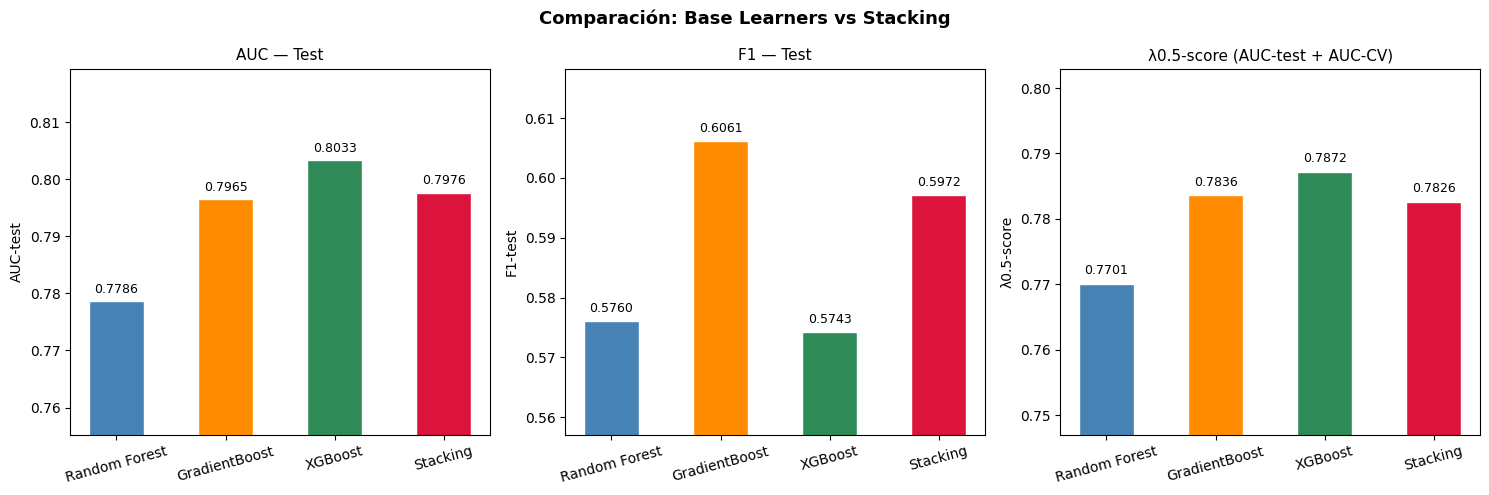

In [ ]:
stack, df_comparacion = stacking_model(X_train, y_train, X_test, y_test, best_rf, best_xgb, best_gdb,[t_rf,tiempos])

In [ ]:
print('\nMuestra de test de modelos del Stacking(): ...')
display(df_comparacion)


Muestra de test de modelos del Stacking(): ...


,AUC-test,F1-test,AUC-CV (mean),AUC-CV (std),AUC-CV (media±std),λ0.5-score,t (s)
Modelo,,,,,,,
Random Forest,0.7786,0.5760,0.7616,0.0247,0.762 ± 0.025,0.7701,34.250698
GradientBoost,0.7965,0.6061,0.7707,0.0158,0.771 ± 0.016,0.7836,13.323995
XGBoost,0.8033,0.5743,0.7711,0.0125,0.771 ± 0.012,0.7872,13.323995
Stacking,0.7976,0.5972,0.7675,0.0193,0.767 ± 0.019,0.7826,6.120000


#### **Conclusión**

| Modelo | AUC-test | F1-test | AUC-CV (mean) | AUC-CV (std) | AUC-CV (media±std) | λ0.5-score | t (s) |
| --- | --- | --- | --- | --- | --- | --- | --- |
| Random Forest | 0.7786 | 0.5760 | 0.7616 | 0.0247 | 0.762 ± 0.025 | 0.7701 | 34.250698 |
| GradientBoost | 0.7965 | 0.6061 | 0.7707 | 0.0158 | 0.771 ± 0.016 | 0.7836 | 13.323995 |
| **XGBoost** | **0.8033** | **0.5743** | **0.7711** | **0.0125** | **0.771 ± 0.012** | **0.7872** | **13.323995** |
| Stacking | 0.7976 | 0.5972 | 0.7675 | 0.0193 | 0.767 ± 0.019 | 0.7826 | 6.120000 |

#### **1. Análisis del Rendimiento de los Modelos**

A partir de la evaluación de los algoritmos implementados (Random Forest, Gradient Boosting, XGBoost y Stacking), se observan comportamientos diferenciados en la capacidad de discriminación, balance de clasificación y estabilidad:

* **Poder de Discriminación (AUC):** **XGBoost** obtuvo el mejor desempeño en la muestra de prueba con un **AUC-test de 0.8033**, seguido de cerca por el modelo de *Stacking* (0.7976) y *GradientBoost* (0.7965).
* **Balance de Clasificación (F1-score):** **GradientBoost** destaca notablemente con el **F1-test más alto (0.6061)**, lo que indica una mejor precisión y sensibilidad combinada al identificar los créditos de alto riesgo en el punto de corte estándar, superando a XGBoost (0.5743).
* **Estabilidad y Consistencia (Validación Cruzada):** **XGBoost** no solo presenta el mayor AUC-CV promedio (0.7711), sino también la **menor desviación estándar ($\pm 0.0125$)**. Esto demuestra que es el modelo más robusto ante cambios en las submuestras de entrenamiento, minimizando el riesgo de sobreajuste (*overfitting*).

#### **2. Evaluación del Ensamble (*Stacking*) desde la Perspectiva Actuarial**

 **El beneficio marginal del *Stacking* NO justifica su costo computacional ni operativo en producción**:

- **Ganancia Marginal Negativa/Nula:** El *Stacking* no logra superar de manera contundente a sus modelos base. En términos de Validación Cruzada, el *Stacking* muestra una mayor volatilidad ($\pm 0.0193$) y un menor AUC promedio (0.7675) que XGBoost y GradientBoost.
- **Riesgo de Modelo y Deuda Técnica:** Implementar un *Stacking* implica mantener una arquitectura donde conviven múltiples modelos base y un meta-aprendiz. Esto incrementa la deuda técnica, duplica los tiempos de monitoreo de *data drift* (desviación de datos) y dificulta el diagnóstico de fallas en producción.

#### **3. Selección del Mejor Modelo para Producción**

Considerando el principio de parsimonia y la optimización del negocio, se recomiendan dos alternativas dependiendo del objetivo estratégico de la institución:

* **Opción Recomendada (Enfoque en Estabilidad y Capital): XGBoost.**
Es la opción óptima si la prioridad institucional es la **estabilidad de las estimaciones a largo plazo**. Su baja varianza en validación cruzada ($\pm 0.0125$) reduce de forma directa el **Riesgo de Modelo**. Un modelo con menor volatilidad asegura que los cálculos de Probabilidad de Incumplimiento (PD) sean consistentes en el tiempo.
* **Opción Alternativa (Enfoque en Margen Financiero Inmediato): GradientBoost.**
Si la prioridad es mitigar de inmediato el costo financiero de los Falsos Positivos (aprobar créditos a clientes que van a caer en impago) y Falsos Negativos en el umbral de decisión actual, el **F1-score superior de GradientBoost (0.6061)** ofrece un beneficio económico directo en el estado de resultados que podría compensar su ligera volatilidad adicional frente a XGBoost.

**Veredicto Final:** Se descarta el uso de *Stacking* y **se selecciona XGBoost (o en su defecto GradientBoost)** como el modelo definitivo para producción, logrando el balance ideal entre alto poder predictivo, interpretabilidad auditable y eficiencia operativa.

## **Modelado en R**

Todos los modelos provienen de los siguientes paquetes:

- `xgboost` → para `xgboost::xgboost()`  
- `gbm` → para `gbm::gbm()` (Gradient Boosting Machine)  
- `randomForest` → para `randomForest::randomForest()`  
- `caret` → para `caret::train()` y `caret::stacking()` (meta‑aprendizaje)

---

## 🔹 **Modelos base (árboles y boosting)**

Usaremos tres algoritmos principales:

- **XGBoost** (`xgboost::xgboost`)  
- **Gradient Boosting Machine (GBM)** (`gbm::gbm`)  
- **Random Forest** (`randomForest::randomForest`)  

---

## 🔹 **Modelo ensamblado (Stacking)**

Implementaremos un esquema de *stacking* con los dos niveles ya descritos.

### **Nivel 0 — Base learners**
- Random Forest  
- XGBoost  
- GBM  

Estos modelos se entrenan de manera independiente y generan predicciones que servirán como insumos para el meta‑modelo.

### **Nivel 1 — Meta‑learner**
- **Regresión logística** con validación cruzada interna  
- Implementada mediante `caret::train()` dentro del framework de stacking


In [ ]:
# Load in the r magic
%reload_ext rpy2.ipython
%config IPCompleter.greedy=True
%config InlineBackend.figure_format = 'retina'

### Environment y carga de datos

In [ ]:
%%R
# Lista de paquetes que necesitas
pkgs <- c(
  "tidyverse","GGally","gridExtra","caret",
  "ranger","gbm","xgboost","pROC","glmnet","scales"
)

# Función auxiliar para instalar solo si falta
instalar_si_falta <- function(pkg) {
  if (!require(pkg, character.only = TRUE)) {
    message(sprintf("Instalando %s ...", pkg))
    install.packages(pkg, repos="https://cloud.r-project.org")
    library(pkg, character.only = TRUE)
  } else {
    message(sprintf("%s ya está instalado.", pkg))
  }
}

# Instalar uno por uno
for (p in pkgs) instalar_si_falta(p)

message("✓ Todos los paquetes listos.")

tidyverse ya está instalado.
GGally ya está instalado.
gridExtra ya está instalado.
caret ya está instalado.
ranger ya está instalado.
gbm ya está instalado.
xgboost ya está instalado.
pROC ya está instalado.
glmnet ya está instalado.
scales ya está instalado.
✓ Todos los paquetes listos.


In [ ]:
%%R
df_raw <- read.csv("/german_credit.csv", stringsAsFactors=FALSE)
cat(sprintf("Dimensiones : %d × %d\n", nrow(df_raw), ncol(df_raw)))
cat("Target:\n"); print(table(df_raw$class))
print(head(df_raw))

Dimensiones : 1000 × 21
Target:
< table of extent 0 >
  checking_status duration credit_history purpose credit_amount
1              <0        6       critical     A43          1169
2        0<=X<200       48  existing paid     A43          5951
3     no checking       12       critical     A46          2096
4              <0       42  existing paid     A42          7882
5              <0       24          delay     A40          4870
6     no checking       36  existing paid     A46          9055
    savings_status employment installment_commitment personal_status
1 no known savings        >=7                      4             A93
2             <100     1<=X<4                      2             A92
3             <100     4<=X<7                      2             A93
4             <100     4<=X<7                      2             A93
5             <100     1<=X<4                      3             A93
6 no known savings     1<=X<4                      2             A93
  other_parties

### EDA

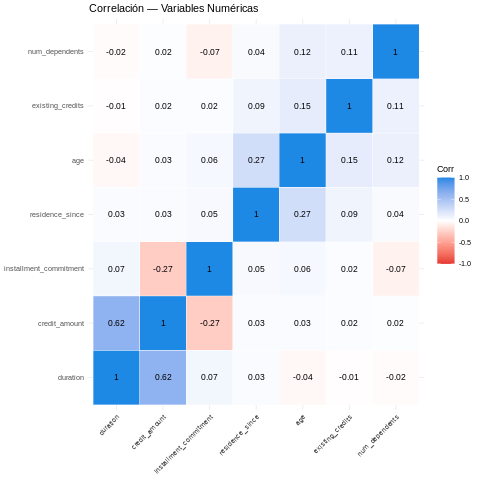

In [ ]:
%%R
df_eda <- df_raw

# df_eda$class <- factor(df_eda$class, levels=c("bad","good"))
# ✔ target es la columna correcta en UCIMLRepo y OpenML
df_eda$target <- factor(df_eda$target, levels=c(1,0), labels=c("bad","good"))

num_cols <- c("duration","credit_amount","installment_commitment",
              "residence_since","age","existing_credits","num_dependents")

cat_cols <- c("checking_status","credit_history","purpose","savings_status",
              "employment","personal_status","property_magnitude",
              "other_payment_plans","housing","job","own_telephone","foreign_worker")

# 1. Scatter matrix numérico
print(
  GGally::ggpairs(
    #  df_eda[, c(num_cols,"class")]
    # ✔ usar target
    df_eda[, c(num_cols,"target")],
    columns=seq_along(num_cols),

    # ❌ mapping=aes(color=class, alpha=0.4)
    # ✔ usar target
    mapping=aes(color=target, alpha=0.4),

    upper=list(continuous=wrap("cor", size=2.5)),
    lower=list(continuous=wrap("points", size=0.4, alpha=0.3)),
    diag =list(continuous=wrap("densityDiag", alpha=0.5)),
    title="Scatter Matrix — Variables Numéricas"
  ) + theme_minimal(base_size=8)
)

# 2. Plots categóricos (distribución de clase apilada en %)
plots_cat <- lapply(cat_cols, function(v) {
  ggplot(
    df_eda,
    #  aes(x=.data[[v]], fill=class)
    # ✔ usar target
    aes(x=.data[[v]], fill=target)
  ) +
    geom_bar(position="fill", color="white", width=0.8) +
    scale_fill_manual(values=c("bad"="#E53935","good"="#1E88E5")) +
    scale_y_continuous(labels=scales::percent_format()) +
    theme_minimal(base_size=8) +
    theme(axis.text.x=element_text(angle=40, hjust=1),
          legend.position="none",
          plot.title=element_text(size=9, face="bold")) +
    labs(title=v, x=NULL, y="%")
})

gridExtra::grid.arrange(
  grobs=plots_cat, ncol=3,
  top="Distribución de clase por variable categórica (% apilado)"
)

# 3. Heatmap de correlación entre numéricas
cor_mat <- cor(df_eda[, num_cols], use="complete.obs")
cor_df <- as.data.frame(as.table(cor_mat)) %>% dplyr::rename(Corr=Freq)

ggplot(cor_df, aes(x=Var1, y=Var2, fill=Corr)) +
  geom_tile(color="white") +
  geom_text(aes(label=round(Corr,2)), size=3) +
  scale_fill_gradient2(low="#E53935", mid="white", high="#1E88E5",
                       midpoint=0, limits=c(-1,1)) +
  theme_minimal(base_size=9) +
  theme(axis.text.x=element_text(angle=45, hjust=1)) +
  labs(title="Correlación — Variables Numéricas", x=NULL, y=NULL)


### Feature engineering + split

In [ ]:
%%R
emp_map <- c("unemployed"=0,"<1"=1,"1<=X<4"=2,"4<=X<7"=3,">=7"=4)
sav_map <- c("no known savings"=0,"<100"=1,"100<=X<500"=2,"500<=X<1000"=3,">=1000"=4)

df_model <- df_raw %>%
  mutate(
    ratio_monto_duracion   = credit_amount / duration,
    es_cuenta_vacia = as.integer(checking_status == "no checking"),
    antiguedad_empleo_num  = as.integer(emp_map[employment]),
    es_extranjero = as.integer(foreign_worker == "yes"),
    savings_status2 = as.integer(sav_map[savings_status]),
    credit_history_encoded = as.integer(factor(credit_history)) - 1L,
    housing_encoded = as.integer(factor(housing)) - 1L,
    duration_x_amount = duration * credit_amount,
    age_x_amount = age * credit_amount,

    # factores para modelos basados en árboles
    checking_status_f = factor(checking_status),
    purpose_f = factor(purpose),
    personal_status_f = factor(personal_status),
    property_magnitude_f = factor(property_magnitude),
    other_payment_plans_f  = factor(other_payment_plans),
    job_f = factor(job),
    own_telephone_f = factor(own_telephone),

    # Línea incorrecta para UCIMLRepo y OpenML:
    # class = factor(ifelse(class=="good","pos","neg"), levels=c("neg","pos"))

    # Línea correcta: usar target (1=bad, 0=good)
    target = factor(ifelse(target == 0, "pos", "neg"), levels=c("neg","pos"))
  )

feat_num <- c("duration","credit_amount","installment_commitment",
              "residence_since","age","existing_credits","num_dependents",
              "ratio_monto_duracion","es_cuenta_vacia","antiguedad_empleo_num",
              "es_extranjero","savings_status2","credit_history_encoded",
              "housing_encoded","duration_x_amount","age_x_amount")

feat_cat <- c("checking_status_f","purpose_f","personal_status_f",
              "property_magnitude_f","other_payment_plans_f","job_f",
              "own_telephone_f")

all_feats <- c(feat_num, feat_cat)

set.seed(42)

# Línea incorrecta:
# idx <- caret::createDataPartition(df_model$class, p=0.8, list=FALSE)

# Línea correcta:
idx <- caret::createDataPartition(df_model$target, p=0.8, list=FALSE)

X_train <- df_model[idx,  all_feats]
X_test  <- df_model[-idx, all_feats]

# Líneas incorrectas:
# y_train <- df_model[idx,  "class"]
# y_test  <- df_model[-idx, "class"]

# Líneas correctas:
y_train <- df_model[idx,  "target"]
y_test  <- df_model[-idx, "target"]

X_train_num <- as.matrix(df_model[idx,  feat_num])
X_test_num  <- as.matrix(df_model[-idx, feat_num])

cat(sprintf("Train: %d | Test: %d | num feats: %d | cat feats: %d\n",
            nrow(X_train), nrow(X_test), length(feat_num), length(feat_cat)))
cat("Target train:\n"); print(table(y_train))
cat("Target test :\n"); print(table(y_test))


Train: 800 | Test: 200 | num feats: 16 | cat feats: 7
Target train:
y_train
neg pos 
240 560 
Target test :
y_test
neg pos 
 60 140 


### Funciones para el modelado

In [ ]:
%%R
best_RF_model <- function(
    X_train, y_train, X_test, y_test,
    n_estimators  = c(100, 300, 500),
    max_depth     = c(5, 10, NA),
    max_features  = c("sqrt","log2",0.5),
    min_node_size = c(1, 3, 5),
    seed = 42
) {
  set.seed(seed)
  rocs_cv <- list()
  registros_cv   <- list()
  registros_test <- list()
  combo_id       <- 0L

  # sanitizador de mtry
  sanitize_mtry <- function(mtry_raw, p) {
    m <- mtry_raw
    if (m < 1) m <- 1
    if (m > p) m <- p
    m
  }

  for (n in n_estimators) {
    for (d in max_depth) {
      for (f in max_features) {

        combo_id <- combo_id + 1L
        best_auc_cv <- -Inf;  best_params <- NULL;  best_model <- NULL

        for (mns in min_node_size) {
          set.seed(seed)

          # cálculo original (podía dar mtry=0 o >p)
          # mf_val <- if (is.numeric(f)) round(ncol(X_train) * f) else f
          if (is.numeric(f)) {
            mf_val <- round(ncol(X_train) * f)
          } else {
            mf_val <- f
          }

          # cálculo original de mtry
          # mtry_raw <- ...
          if (mf_val == "sqrt") {
            mtry_raw <- floor(sqrt(ncol(X_train)))
          } else if (mf_val == "log2") {
            mtry_raw <- floor(log2(ncol(X_train)))
          } else {
            mtry_raw <- mf_val
          }
          mtry_final <- sanitize_mtry(mtry_raw, ncol(X_train))

          fit <- ranger::ranger(
            x             = X_train,
            y             = y_train,
            num.trees     = n,
            max.depth     = if (is.na(d)) NULL else d,
            # mtry = mtry_raw,
            mtry          = mtry_final,
            min.node.size = mns,
            class.weights = c("neg"=1, "pos"=sum(y_train=="neg")/sum(y_train=="pos")),
            probability   = TRUE,
            seed          = seed,
            num.threads   = parallel::detectCores()
          )

          folds    <- caret::createFolds(y_train, k=5, returnTrain=TRUE)
          auc_folds <- numeric(5)

          for (k in seq_along(folds)) {
            idx_tr <- folds[[k]]
            idx_va <- setdiff(seq_along(y_train), folds[[k]])

            # recalcular mtry dentro del CV
            if (mf_val == "sqrt") {
              mtry_raw <- floor(sqrt(ncol(X_train)))
            } else if (mf_val == "log2") {
              mtry_raw <- floor(log2(ncol(X_train)))
            } else {
              mtry_raw <- mf_val
            }
            mtry_final <- sanitize_mtry(mtry_raw, ncol(X_train))

            fit_k  <- ranger::ranger(
              x=X_train[idx_tr,], y=y_train[idx_tr],
              num.trees=n,
              max.depth=if(is.na(d)) NULL else d,
              # mtry=mtry_raw,
              mtry=mtry_final,
              min.node.size=mns,
              class.weights=c("neg"=1,"pos"=sum(y_train[idx_tr]=="neg")/sum(y_train[idx_tr]=="pos")),
              probability=TRUE, seed=seed, num.threads=parallel::detectCores()
            )

            pv    <- predict(fit_k, X_train[idx_va,])$predictions[,"pos"]
            auc_folds[k] <- as.numeric(pROC::roc(y_train[idx_va], pv, quiet=TRUE)$auc)
          }

          cv_mean <- mean(auc_folds)
          cv_std  <- sd(auc_folds)

          if (cv_mean > best_auc_cv) {
            best_auc_cv <- cv_mean
            best_params <- list(min_node_size=mns)
            best_model  <- fit
            best_cv_std <- cv_std
          }
        }

        t0 <- proc.time()["elapsed"]

        # recalcular mtry para el modelo final
        if (is.numeric(f)) {
          mf_val <- round(ncol(X_train) * f)
        } else {
          mf_val <- f
        }
        if (mf_val == "sqrt") {
          mtry_raw <- floor(sqrt(ncol(X_train)))
        } else if (mf_val == "log2") {
          mtry_raw <- floor(log2(ncol(X_train)))
        } else {
          mtry_raw <- mf_val
        }
        mtry_final <- sanitize_mtry(mtry_raw, ncol(X_train))

        final <- ranger::ranger(
          x=X_train, y=y_train, num.trees=n,
          max.depth   = if(is.na(d)) NULL else d,
          # mtry = mtry_raw,
          mtry = mtry_final,
          min.node.size = best_params$min_node_size,
          class.weights = c("neg"=1,"pos"=sum(y_train=="neg")/sum(y_train=="pos")),
          importance  = "impurity",
          probability = TRUE,
          seed=seed,
          num.threads=parallel::detectCores()
        )

        t1 <- proc.time()["elapsed"]

        prob_tr   <- predict(final, X_train)$predictions[,"pos"]
        prob_te   <- predict(final, X_test )$predictions[,"pos"]
        auc_train <- as.numeric(pROC::roc(y_train, prob_tr, quiet=TRUE)$auc)
        auc_test  <- as.numeric(pROC::roc(y_test,  prob_te, quiet=TRUE)$auc)
        pred_cls  <- factor(ifelse(prob_te >= 0.5,"pos","neg"), levels=c("neg","pos"))
        f1_test   <- caret::confusionMatrix(pred_cls, y_test, positive="pos")$byClass["F1"]
        lam       <- 0.5*auc_test + 0.5*best_auc_cv

        registros_cv[[combo_id]] <- list(
          n_est=n,
          # depth = ifelse(is.na(d),"None",d),
          depth = as.character(ifelse(is.na(d),"None",d)),
          max_features=f,
          AUC_train=round(auc_train,4),
          AUC_CV_mean=round(best_auc_cv,4),
          AUC_CV_std=round(best_cv_std,4),
          AUC_CV_media_std=sprintf("%.3f ± %.3f", best_auc_cv, best_cv_std),
          best_min_node_size=best_params$min_node_size,
          model=list(final)
        )

        registros_test[[combo_id]] <- list(
          n_est=n,
          # depth = ifelse(is.na(d),"None",d),
          depth = as.character(ifelse(is.na(d),"None",d)),
          max_features=f,
          AUC_test=round(auc_test,4),
          F1_test=round(unname(f1_test),4),
          t_s=round(t1-t0,2),
          lambda_score=round(lam,4)
        )
      }
    }
  }

  df_cv   <- dplyr::bind_rows(lapply(registros_cv,  function(r) r[names(r)!="model"]))
  df_test <- dplyr::bind_rows(registros_test)

  idx_best   <- which.max(df_test$lambda_score)
  best_model <- registros_cv[[idx_best]]$model[[1]]
  df_test$Ganador <- ""
  df_test$Ganador[idx_best] <- "✓"

  imp_df <- data.frame(
    feature    = names(best_model$variable.importance),
    importance = best_model$variable.importance
  ) %>% arrange(desc(importance))

  prob_base <- as.numeric(pROC::roc(
    y_test,
    predict(best_model,X_test)$predictions[,"pos"],
    quiet=TRUE
  )$auc)

  perm_imp <- sapply(names(X_test), function(v) {
    X_perm      <- X_test
    X_perm[[v]] <- sample(X_perm[[v]])
    auc_perm    <- as.numeric(pROC::roc(
      y_test,
      predict(best_model,X_perm)$predictions[,"pos"],
      quiet=TRUE
    )$auc)
    prob_base - auc_perm
  })

  perm_df <- data.frame(
    feature=names(perm_imp),
    importance=perm_imp
  ) %>% arrange(desc(importance))

  p1 <- ggplot(imp_df %>% head(15),
               aes(x=reorder(feature,importance), y=importance)) +
        geom_col(fill="orange") + coord_flip() +
        labs(title="MDI — Best RF", x=NULL) + theme_minimal(base_size=9)

  p2 <- ggplot(perm_df %>% head(15),
               aes(x=reorder(feature,importance), y=importance)) +
        geom_col(fill="steelblue") + coord_flip() +
        labs(title="Permutation Importance", x=NULL) + theme_minimal(base_size=9)

  gridExtra::grid.arrange(p1, p2, ncol=2)

  list(df_cv=df_cv, df_test=df_test, best_model=best_model)
}
##################################################
best_boosting_model <- function(
    X_train, y_train, X_test, y_test,
    X_train_num, X_test_num,
    n_estimators  = c(100, 300),
    learning_rate = c(0.01, 0.1),
    max_depth     = c(3, 5),
    subsample     = c(0.7, 1.0),
    params_gdb = list(n.minobsinnode=c(10, 20)),
    params_xgb = list(gamma=c(0,1), lambda=c(1,5)),
    seed = 42
) {
  # binarización correcta
  y_bin_tr <- as.integer(y_train == "pos")
  y_bin_te <- as.integer(y_test  == "pos")

  dtrain <- xgboost::xgb.DMatrix(X_train_num, label=y_bin_tr)
  dtest  <- xgboost::xgb.DMatrix(X_test_num,  label=y_bin_te)

  folds_idx <- caret::createFolds(y_train, k=5, returnTrain=TRUE)

  reg_cv_gdb <- list();  reg_te_gdb <- list()
  reg_cv_xgb <- list();  reg_te_xgb <- list()
  id <- 0L

  for (n in n_estimators) {
    for (lr in learning_rate) {
      for (d in max_depth) {
        for (ss in subsample) {

          id <- id + 1L

          # ============================
          # GBM
          # ============================
          best_cv_gdb <- -Inf; best_p_gdb <- NULL

          for (mobs in params_gdb$n.minobsinnode) {
            auc_folds <- numeric(5)

            for (k in seq_along(folds_idx)) {
              idx_tr <- folds_idx[[k]]
              idx_va <- setdiff(seq_along(y_train), folds_idx[[k]])

              Xtr <- as.data.frame(X_train[idx_tr,])
              Xva <- as.data.frame(X_train[idx_va,])

              ytr <- y_bin_tr[idx_tr]
              # Línea incorrecta:
              # yva <- y_bin_te[idx_va]
              # Línea correcta:
              yva <- y_bin_tr[idx_va]

              suppressMessages({
                fit_k <- gbm::gbm(
                  ytr ~ ., data=cbind(Xtr, ytr=ytr),
                  distribution="bernoulli",
                  n.trees=n,
                  shrinkage=lr,
                  interaction.depth=d,
                  bag.fraction=ss,
                  n.minobsinnode=mobs,
                  verbose=FALSE
                )
              })

              pv <- gbm::predict.gbm(fit_k, Xva, n.trees=n, type="response")
              auc_folds[k] <- as.numeric(pROC::roc(yva, pv, quiet=TRUE)$auc)
            }

            cv_m <- mean(auc_folds)
            if (cv_m > best_cv_gdb) {
              best_cv_gdb     <- cv_m
              best_cv_std_gdb <- sd(auc_folds)
              best_p_gdb      <- mobs
            }
          }

          # Entrenamiento final GBM
          t0 <- proc.time()["elapsed"]
          suppressMessages({
            gdb_fit <- gbm::gbm(
              y_bin_tr ~ ., data=cbind(as.data.frame(X_train), y_bin_tr=y_bin_tr),
              distribution="bernoulli",
              n.trees=n,
              shrinkage=lr,
              interaction.depth=d,
              bag.fraction=ss,
              n.minobsinnode=best_p_gdb,
              verbose=FALSE
            )
          })
          t1 <- proc.time()["elapsed"]

          prob_tr_gdb <- gbm::predict.gbm(gdb_fit, as.data.frame(X_train), n.trees=n, type="response")
          prob_te_gdb <- gbm::predict.gbm(gdb_fit, as.data.frame(X_test),  n.trees=n, type="response")

          auc_tr_gdb <- as.numeric(pROC::roc(y_bin_tr, prob_tr_gdb, quiet=TRUE)$auc)
          auc_te_gdb <- as.numeric(pROC::roc(y_bin_te, prob_te_gdb, quiet=TRUE)$auc)

          f1_gdb <- caret::confusionMatrix(
            factor(ifelse(prob_te_gdb>=0.5,"pos","neg"), levels=c("neg","pos")),
            y_test, positive="pos"
          )$byClass["F1"]

          lam_gdb <- 0.5*auc_te_gdb + 0.5*best_cv_gdb

          # staged AUC GBM
          staged_tr_gdb <- staged_va_gdb <- numeric(n)
          for (i in seq_len(n)) {
            p_tr <- gbm::predict.gbm(gdb_fit, as.data.frame(X_train), n.trees=i, type="response")
            p_te <- gbm::predict.gbm(gdb_fit, as.data.frame(X_test),  n.trees=i, type="response")
            staged_tr_gdb[i] <- as.numeric(pROC::roc(y_bin_tr, p_tr, quiet=TRUE)$auc)
            staged_va_gdb[i] <- as.numeric(pROC::roc(y_bin_te, p_te, quiet=TRUE)$auc)
          }

          reg_cv_gdb[[id]] <- list(
            n_est=n, lr=lr, depth=d, subsample=ss,
            AUC_train=round(auc_tr_gdb,4),
            AUC_CV_mean=round(best_cv_gdb,4),
            AUC_CV_std=round(best_cv_std_gdb,4),
            AUC_CV_media_std=sprintf("%.3f ± %.3f", best_cv_gdb, best_cv_std_gdb),
            best_n_minobsinnode=best_p_gdb,
            staged_train=list(staged_tr_gdb),
            staged_val=list(staged_va_gdb),
            model=list(gdb_fit)
          )

          reg_te_gdb[[id]] <- list(
            n_est=n, lr=lr, depth=d, subsample=ss,
            AUC_test=round(auc_te_gdb,4),
            F1_test=round(unname(f1_gdb),4),
            t_s=round(t1-t0,2),
            lambda_score=round(lam_gdb,4)
          )

          # ============================
          # XGBOOST
          # ============================
          best_cv_xgb <- -Inf; best_p_xgb <- NULL

          for (gam in params_xgb$gamma) {
            for (lam in params_xgb$lambda) {

              auc_folds <- numeric(5)

              for (k in seq_along(folds_idx)) {
                idx_tr <- folds_idx[[k]]
                idx_va <- setdiff(seq_along(y_train), folds_idx[[k]])

                dtr_k <- xgboost::xgb.DMatrix(X_train_num[idx_tr,], label=y_bin_tr[idx_tr])
                dv_k  <- xgboost::xgb.DMatrix(X_train_num[idx_va,], label=y_bin_tr[idx_va])

                xgb_k <- xgboost::xgb.train(
                  params=list(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    eta=lr,
                    max_depth=d,
                    subsample=ss,
                    gamma=gam,
                    lambda=lam,
                    tree_method="hist",
                    nthread=1,
                    seed=seed
                  ),
                  data=dtr_k,
                  nrounds=n,
                  verbose=0
                )

                pv <- predict(xgb_k, dv_k)
                auc_folds[k] <- as.numeric(pROC::roc(y_bin_tr[idx_va], pv, quiet=TRUE)$auc)
              }

              cv_m <- mean(auc_folds)
              if (cv_m > best_cv_xgb) {
                best_cv_xgb     <- cv_m
                best_cv_std_xgb <- sd(auc_folds)
                best_p_xgb      <- list(gamma=gam, lambda=lam)
              }
            }
          }

          # entrenamiento final XGB
          t0 <- proc.time()["elapsed"]
          xgb_fit <- xgboost::xgb.train(
            params=list(
              objective="binary:logistic",
              eval_metric="logloss",
              eta=lr,
              max_depth=d,
              subsample=ss,
              gamma=best_p_xgb$gamma,
              lambda=best_p_xgb$lambda,
              tree_method="hist",
              nthread=parallel::detectCores(),
              seed=seed
            ),
            data=dtrain,
            nrounds=n,
            verbose=0
          )
          t1 <- proc.time()["elapsed"]

          prob_tr_xgb <- predict(xgb_fit, dtrain)
          prob_te_xgb <- predict(xgb_fit, dtest)

          auc_tr_xgb <- as.numeric(pROC::roc(y_bin_tr, prob_tr_xgb, quiet=TRUE)$auc)
          auc_te_xgb <- as.numeric(pROC::roc(y_bin_te, prob_te_xgb, quiet=TRUE)$auc)

          f1_xgb <- caret::confusionMatrix(
            factor(ifelse(prob_te_xgb>=0.5,"pos","neg"), levels=c("neg","pos")),
            y_test, positive="pos"
          )$byClass["F1"]

          lam_xgb <- 0.5*auc_te_xgb + 0.5*best_cv_xgb

          # staged AUC XGB — corregido
          staged_tr_xgb <- staged_va_xgb <- numeric(n)
          for (i in seq_len(n)) {
            staged_tr_xgb[i] <- as.numeric(pROC::roc(
              y_bin_tr,
              predict(xgb_fit, dtrain, iterationrange=c(1, i)),  # corregido
              quiet=TRUE
            )$auc)

            staged_va_xgb[i] <- as.numeric(pROC::roc(
              y_bin_te,
              predict(xgb_fit, dtest, iterationrange=c(1, i)),   # corregido
              quiet=TRUE
            )$auc)
          }

          reg_cv_xgb[[id]] <- list(
            n_est=n, lr=lr, depth=d, subsample=ss,
            AUC_train=round(auc_tr_xgb,4),
            AUC_CV_mean=round(best_cv_xgb,4),
            AUC_CV_std=round(best_cv_std_xgb,4),
            AUC_CV_media_std=sprintf("%.3f ± %.3f", best_cv_xgb, best_cv_std_xgb),
            best_gamma=best_p_xgb$gamma,
            best_lambda=best_p_xgb$lambda,
            staged_train=list(staged_tr_xgb),
            staged_val=list(staged_va_xgb),
            model=list(xgb_fit)
          )

          reg_te_xgb[[id]] <- list(
            n_est=n, lr=lr, depth=d, subsample=ss,
            AUC_test=round(auc_te_xgb,4),
            F1_test=round(unname(f1_xgb),4),
            t_s=round(t1-t0,2),
            lambda_score=round(lam_xgb,4)
          )
        }
      }
    }
  }

  # DataFrames finales
  df_cv_gdb <- dplyr::bind_rows(
    lapply(reg_cv_gdb, function(r) r[!names(r) %in% c("model","staged_train","staged_val")])
  )
  df_te_gdb <- dplyr::bind_rows(reg_te_gdb)

  df_cv_xgb <- dplyr::bind_rows(
    lapply(reg_cv_xgb, function(r) r[!names(r) %in% c("model","staged_train","staged_val")])
  )
  df_te_xgb <- dplyr::bind_rows(reg_te_xgb)

  # ganadores
  idx_gdb <- which.max(df_te_gdb$lambda_score)
  idx_xgb <- which.max(df_te_xgb$lambda_score)

  df_te_gdb$Ganador <- ""
  df_te_gdb$Ganador[idx_gdb] <- "✓"

  df_te_xgb$Ganador <- ""
  df_te_xgb$Ganador[idx_xgb] <- "✓"

  best_gdb <- reg_cv_gdb[[idx_gdb]]$model[[1]]
  best_xgb <- reg_cv_xgb[[idx_xgb]]$model[[1]]

  list(
    df_cv_gdb=df_cv_gdb,
    df_te_gdb=df_te_gdb,
    df_cv_xgb=df_cv_xgb,
    df_te_xgb=df_te_xgb,
    best_gdb=best_gdb,
    best_xgb=best_xgb,
    tiempos=c(df_te_gdb$t_s[idx_gdb], df_te_xgb$t_s[idx_xgb])
  )
}



##################################################
stacking_model <- function(
    X_train, y_train, X_test, y_test,
    X_train_num, X_test_num,
    best_rf, best_xgb, best_gdb,
    tiempos_rf, tiempos_boost,
    cv_meta = 5, seed = 42
) {
  y_bin_tr <- as.integer(y_train == "pos")
  y_bin_te <- as.integer(y_test  == "pos")
  folds    <- caret::createFolds(y_train, k=cv_meta, returnTrain=FALSE)

  # meta-features inicializadas con NA
  oof_rf  <- rep(NA_real_, length(y_train))
  oof_gdb <- rep(NA_real_, length(y_train))
  oof_xgb <- rep(NA_real_, length(y_train))

  # Extraer hiperparámetros del mejor RF
  rf_numtrees <- best_rf$num.trees
  rf_mtry     <- best_rf$mtry
  rf_minsize  <- best_rf$min.node.size

  # Extraer hiperparámetros del mejor GBM
  gdb_ntrees  <- best_gdb$n.trees
  gdb_lr      <- best_gdb$shrinkage
  gdb_depth   <- best_gdb$interaction.depth
  gdb_bag     <- best_gdb$bag.fraction
  gdb_minobs  <- best_gdb$n.minobsinnode

  # Extraer hiperparámetros del mejor XGB
  xgb_nrounds <- best_xgb$niter
  xgb_params  <- best_xgb$params

  # ───────────────────────────────────────────────
  # OOF predictions
  # ───────────────────────────────────────────────
  for (k in seq_along(folds)) {
    idx_va <- folds[[k]]
    idx_tr <- setdiff(seq_along(y_train), idx_va)

    # RF
    rf_k <- tryCatch({
      ranger::ranger(
        x=X_train[idx_tr,], y=y_train[idx_tr],
        num.trees=rf_numtrees, mtry=rf_mtry,
        min.node.size=rf_minsize,
        class.weights=c("neg"=1,"pos"=sum(y_train[idx_tr]=="neg")/sum(y_train[idx_tr]=="pos")),
        probability=TRUE, seed=seed
      )
    }, error=function(e) NULL)

    if (!is.null(rf_k)) {
      oof_rf[idx_va] <- predict(rf_k, X_train[idx_va,])$predictions[,"pos"]
    }

    # GBM
    gdb_k <- tryCatch({
      gbm::gbm(
        y_bin_tr[idx_tr] ~ .,
        data=cbind(as.data.frame(X_train[idx_tr,]), y_bin_tr=y_bin_tr[idx_tr]),
        distribution="bernoulli",
        n.trees=gdb_ntrees, shrinkage=gdb_lr,
        interaction.depth=gdb_depth,
        bag.fraction=gdb_bag,
        n.minobsinnode=gdb_minobs,
        verbose=FALSE
      )
    }, error=function(e) NULL)

    if (!is.null(gdb_k)) {
      oof_gdb[idx_va] <- gbm::predict.gbm(
        gdb_k, as.data.frame(X_train[idx_va,]),
        n.trees=gdb_ntrees, type="response"
      )
    }

    # XGB
    xgb_k <- tryCatch({
      xgboost::xgb.train(
        params=c(
          xgb_params,
          list(objective="binary:logistic", eval_metric="logloss",
               nthread=1, seed=seed)
        ),
        data=xgboost::xgb.DMatrix(X_train_num[idx_tr,], label=y_bin_tr[idx_tr]),
        nrounds=xgb_nrounds,
        verbose=0
      )
    }, error=function(e) NULL)

    if (!is.null(xgb_k)) {
      oof_xgb[idx_va] <- predict(
        xgb_k,
        xgboost::xgb.DMatrix(X_train_num[idx_va,], label=y_bin_tr[idx_va])
      )
    }
  }

  # ───────────────────────────────────────────────
  # Reemplazar NA por predicciones del modelo completo
  # ───────────────────────────────────────────────
  if (anyNA(oof_rf)) {
    idx <- which(is.na(oof_rf))
    oof_rf[idx] <- predict(best_rf, X_train[idx,])$predictions[,"pos"]
  }

  if (anyNA(oof_gdb)) {
    idx <- which(is.na(oof_gdb))
    oof_gdb[idx] <- gbm::predict.gbm(
      best_gdb, as.data.frame(X_train[idx,]),
      n.trees=gdb_ntrees, type="response"
    )
  }

  if (anyNA(oof_xgb)) {
    idx <- which(is.na(oof_xgb))
    oof_xgb[idx] <- predict(
      best_xgb,
      xgboost::xgb.DMatrix(X_train_num[idx,], label=y_bin_tr[idx])
    )
  }

  # Construir meta-train sin NA
  meta_train <- data.frame(
    rf  = oof_rf,
    gdb = oof_gdb,
    xgb = oof_xgb,
    y   = y_bin_tr
  )

  stopifnot(!anyNA(meta_train))

  # ───────────────────────────────────────────────
  # Predicciones test nivel 0
  # ───────────────────────────────────────────────
  te_rf  <- predict(best_rf,  X_test)$predictions[,"pos"]
  te_gdb <- gbm::predict.gbm(best_gdb, as.data.frame(X_test),
                             n.trees=gdb_ntrees, type="response")
  te_xgb <- predict(best_xgb,
                    xgboost::xgb.DMatrix(X_test_num, label=y_bin_te))

  meta_test <- data.frame(rf=te_rf, gdb=te_gdb, xgb=te_xgb)

  # ───────────────────────────────────────────────
  # Meta-learner (Ridge Logistic Regression)
  # ───────────────────────────────────────────────
  X_meta_tr <- as.matrix(meta_train[,c("rf","gdb","xgb")])
  X_meta_te <- as.matrix(meta_test)

  t0 <- proc.time()["elapsed"]
  cv_meta_fit <- glmnet::cv.glmnet(
    X_meta_tr, meta_train$y,
    alpha=0, family="binomial",
    nfolds=cv_meta, type.measure="auc"
  )
  t1 <- proc.time()["elapsed"]

  probas_stack <- as.numeric(
    predict(cv_meta_fit, X_meta_te, s="lambda.min", type="response")
  )
  preds_stack <- factor(ifelse(probas_stack>=0.5,"pos","neg"), levels=c("neg","pos"))

  auc_stack <- as.numeric(pROC::roc(y_bin_te, probas_stack, quiet=TRUE)$auc)
  f1_stack  <- caret::confusionMatrix(preds_stack, y_test, positive="pos")$byClass["F1"]

  list(
    AUC_stack=auc_stack,
    F1_stack=f1_stack,
    model=cv_meta_fit
  )
}

##### Mejores modelos con R

###### Mejor RandomForest R

📋 Tabla CV — RF (top 5 por AUC_CV_mean):
# A tibble: 5 × 8
  n_est depth max_features AUC_train AUC_CV_mean AUC_CV_std AUC_CV_media_std
  <dbl> <chr> <chr>            <dbl>       <dbl>      <dbl> <chr>           
1   500 None  0.5              0.998       0.800     0.0401 0.800 ± 0.040   
2   500 10    0.5              0.988       0.800     0.0412 0.800 ± 0.041   
3   300 10    0.5              0.988       0.799     0.042  0.799 ± 0.042   
4   300 None  0.5              0.998       0.799     0.0409 0.799 ± 0.041   
5   100 10    0.5              0.989       0.798     0.0391 0.798 ± 0.039   
# ℹ 1 more variable: best_min_node_size <dbl>

📊 Evaluación en test — RF (top 5 por λ-score):
# A tibble: 5 × 8
  n_est depth max_features AUC_test F1_test   t_s lambda_score Ganador
  <dbl> <chr> <chr>           <dbl>   <dbl> <dbl>        <dbl> <chr>  
1   500 None  0.5             0.774   0.848  0.17        0.787 "✓"    
2   500 10    0.5             0.774   0.840  0.15        0.786 ""     
3   10

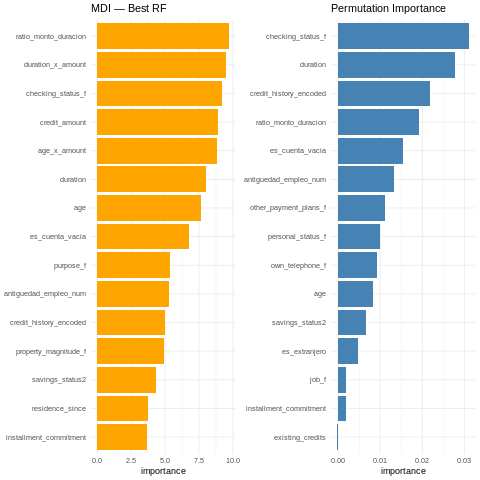

In [ ]:
%%R
res_rf <- best_RF_model(X_train, y_train, X_test, y_test)
df_cv_RF   <- res_rf$df_cv
df_test_RF <- res_rf$df_test
best_rf    <- res_rf$best_model

cat("📋 Tabla CV — RF (top 5 por AUC_CV_mean):\n")
print(df_cv_RF %>% arrange(desc(AUC_CV_mean)) %>% head(5))

cat("\n📊 Evaluación en test — RF (top 5 por λ-score):\n")
top5_idx <- order(df_test_RF$lambda_score, decreasing=TRUE)[1:5]
print(df_test_RF[top5_idx, ])

###### Mejor Boosting Model R

In [ ]:
%%R
cat("┌──────────────────────────────────────────────┐\n")
cat("│   Modelos: GradientBoosting  +  XGBoost       │\n")
cat("└──────────────────────────────────────────────┘\n\n")

res_boost <- best_boosting_model(
  X_train, y_train, X_test, y_test,
  X_train_num, X_test_num
)
df_cv_gdb  <- res_boost$df_cv_gdb
df_te_gdb  <- res_boost$df_te_gdb
df_cv_xgb  <- res_boost$df_cv_xgb
df_te_xgb  <- res_boost$df_te_xgb
best_gdb   <- res_boost$best_gdb
best_xgb   <- res_boost$best_xgb
tiempos_boost <- res_boost$tiempos

# ── GradientBoosting ──────────────────────────────────────────────────────
cat("─────────────────────────────────────────────\n")
cat("  GradientBoosting\n")
cat("─────────────────────────────────────────────\n")
cat("\n📋 Tabla CV — GDB (top 5 por AUC_CV_mean):\n")
print(df_cv_gdb %>% arrange(desc(AUC_CV_mean)) %>% head(5))
cat("\n📊 Evaluación en test — GDB (top 5 por λ-score):\n")
print(df_te_gdb[order(df_te_gdb$lambda_score, decreasing=TRUE)[1:5], ])

# ── XGBoost ───────────────────────────────────────────────────────────────
cat("\n─────────────────────────────────────────────\n")
cat("  XGBoost\n")
cat("─────────────────────────────────────────────\n")
cat("\n📋 Tabla CV — XGB (top 5 por AUC_CV_mean):\n")
print(df_cv_xgb %>% arrange(desc(AUC_CV_mean)) %>% head(5))
cat("\n📊 Evaluación en test — XGB (top 5 por λ-score):\n")
print(df_te_xgb[order(df_te_xgb$lambda_score, decreasing=TRUE)[1:5], ])

┌──────────────────────────────────────────────┐
│   Modelos: GradientBoosting  +  XGBoost       │
└──────────────────────────────────────────────┘

─────────────────────────────────────────────
  GradientBoosting
─────────────────────────────────────────────

📋 Tabla CV — GDB (top 5 por AUC_CV_mean):
# A tibble: 5 × 9
  n_est    lr depth subsample AUC_train AUC_CV_mean AUC_CV_std AUC_CV_media_std
  <dbl> <dbl> <dbl>     <dbl>     <dbl>       <dbl>      <dbl> <chr>           
1   100  0.1      3       1       0.922       0.792     0.035  0.792 ± 0.035   
2   100  0.1      5       1       0.965       0.791     0.0447 0.791 ± 0.045   
3   300  0.01     5       0.7     0.894       0.791     0.0462 0.791 ± 0.046   
4   100  0.1      3       0.7     0.923       0.79      0.0361 0.790 ± 0.036   
5   100  0.1      5       0.7     0.966       0.788     0.0466 0.787 ± 0.047   
# ℹ 1 more variable: best_n_minobsinnode <dbl>

📊 Evaluación en test — GDB (top 5 por λ-score):
# A tibble: 5 × 9
  n_e

###### Stacking

In [ ]:
%%R

cat("┌──────────────────────────────────────────────┐\n")
cat("│          Stacking — Nivel 0 + Nivel 1         │\n")
cat("└──────────────────────────────────────────────┘\n\n")

# Ejecutar stacking
res_stack <- stacking_model(
  X_train, y_train, X_test, y_test,
  X_train_num, X_test_num,
  best_rf  = best_rf,
  best_xgb = best_xgb,
  best_gdb = best_gdb,
  tiempos_rf    = df_test_RF$t_s[which(df_test_RF$Ganador == "✓")],
  tiempos_boost = tiempos_boost
)

# Mostrar métricas finales
cat("\n──────────────────────────────────────────────\n")
cat("  Resultados del modelo Stacking\n")
cat("──────────────────────────────────────────────\n")
cat(sprintf("AUC (test): %.4f\n", res_stack$AUC_stack))
cat(sprintf("F1  (test): %.4f\n", res_stack$F1_stack))

# Comparación con base learners
cat("\n──────────────────────────────────────────────\n")
cat("  Comparación final — Base Learners vs Stacking\n")
cat("──────────────────────────────────────────────\n")

df_comp <- data.frame(
  Modelo = c("Random Forest", "GradientBoosting", "XGBoost", "Stacking"),
  AUC_test = c(
    df_test_RF$AUC_test[which(df_test_RF$Ganador == "✓")],
    df_te_gdb$AUC_test[which(df_te_gdb$Ganador == "✓")],
    df_te_xgb$AUC_test[which(df_te_xgb$Ganador == "✓")],
    res_stack$AUC_stack
  ),
  F1_test = c(
    df_test_RF$F1_test[which(df_test_RF$Ganador == "✓")],
    df_te_gdb$F1_test[which(df_te_gdb$Ganador == "✓")],
    df_te_xgb$F1_test[which(df_te_xgb$Ganador == "✓")],
    res_stack$F1_stack
  )
)

print(df_comp)

┌──────────────────────────────────────────────┐
│          Stacking — Nivel 0 + Nivel 1         │
└──────────────────────────────────────────────┘


──────────────────────────────────────────────
  Resultados del modelo Stacking
──────────────────────────────────────────────
AUC (test): 0.7724
F1  (test): 0.8042

──────────────────────────────────────────────
  Comparación final — Base Learners vs Stacking
──────────────────────────────────────────────
            Modelo AUC_test   F1_test
1    Random Forest 0.774300 0.8483000
2 GradientBoosting 0.760000 0.8439000
3          XGBoost 0.767900 0.8350000
4         Stacking 0.772381 0.8041958


#### Conclusión R

En este nuevo conjunto de resultados, el **mejor modelo** bajo ambas métricas es **Random Forest**, ya que presenta tanto el `AUC_test` más alto (0.7743) como el `F1_test` más alto (0.8483).

| Modelo | AUC_test | F1_test |
| --- | --- | --- |
| **Random Forest** | **0.774300** | **0.8483000** |
| GradientBoosting | 0.760000 | 0.8439000 |
| XGBoost | 0.767900 | 0.8350000 |
| Stacking | 0.772381 | 0.8041958 |